<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 60px 40px; border-radius: 16px; text-align: center; margin-bottom: 30px;">
  <h1 style="color: #e94560; font-size: 2.8em; font-weight: 800; margin: 0; letter-spacing: 2px;">🧑‍💼 Employee Attrition Prediction</h1>
  <h2 style="color: #a8dadc; font-size: 1.4em; margin: 15px 0 5px 0; font-weight: 400;">Workforce Retention Analytics & Machine Learning</h2>
  <p style="color: #ccc; margin: 10px 0; font-size: 1em;">IBM HR Analytics Dataset &nbsp;|&nbsp; End-to-End ML Portfolio Project</p>
  <p style="color: #888; font-size: 0.9em;">Python · Scikit-learn · XGBoost · Seaborn · Explainable AI</p>
</div>


---
# 📋 Executive Summary

## Business Problem
Employee attrition — the voluntary or involuntary departure of employees from an organization — is one of the most **costly and operationally disruptive** challenges facing modern HR departments. The IBM HR Analytics dataset contains **1,470 employee records** with 35 features spanning demographics, job characteristics, satisfaction scores, and compensation data.

## Project Goals
1. **Predict** which employees are at risk of leaving (classification task)
2. **Identify** the top business drivers of attrition
3. **Quantify** risk via probability scores


---
# 2. 📦 Import Libraries


In [16]:
# ============================================================
# CORE LIBRARIES
# ============================================================
import numpy as np
import pandas as pd
import warnings
import os
from collections import Counter

# ============================================================
# VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

# ============================================================
# SKLEARN — PREPROCESSING & SELECTION
# ============================================================
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    RandomizedSearchCV, GridSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# ============================================================
# SKLEARN — MODELS
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC

# ============================================================
# SKLEARN — EVALUATION
# ============================================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

# ============================================================
# XGBOOST
# ============================================================
from xgboost import XGBClassifier

# ============================================================
# SETTINGS
# ============================================================
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# ---- Professional Plot Style ----
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'axes.titlecolor':  '#e6edf3',
    'axes.titlesize':   14,
    'axes.labelsize':   12,
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'figure.titlesize': 16,
    'font.family':      'DejaVu Sans',
})

PALETTE = {'No': '#238636', 'Yes': '#e94560'}
ACCENT   = '#58a6ff'
RED      = '#e94560'
GREEN    = '#238636'

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ All libraries imported successfully.')
print(f'   NumPy    {np.__version__}')
print(f'   Pandas   {pd.__version__}')


✅ All libraries imported successfully.
   NumPy    2.0.2
   Pandas   2.2.2


---
# 3. 📂 Load Dataset


In [17]:
# ---- Load ----
DATA_PATH = '/content/drive/MyDrive/data project /WA_Fn-UseC_-HR-Employee-Attrition.csv'
df_raw = pd.read_csv(DATA_PATH)

print('=' * 60)
print('  IBM HR Employee Attrition — Dataset Loaded')
print('=' * 60)
print(f'  Rows    : {df_raw.shape[0]:,}')
print(f'  Columns : {df_raw.shape[1]}')
print('=' * 60)

df_raw.head(10)


  IBM HR Employee Attrition — Dataset Loaded
  Rows    : 1,470
  Columns : 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,80,2,17,3,2,7,7,7,7


In [18]:
# ---- Random Sample ----
print('Random Sample of 5 Records:')
df_raw.sample(5, random_state=RANDOM_STATE)


Random Sample of 5 Records:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1041,28,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,4,Male,84,3,2,Sales Executive,1,Single,8463,23490,0,Y,No,18,3,4,80,0,6,4,3,5,4,1,3
184,53,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,4,Female,57,4,2,Manufacturing Director,1,Divorced,4450,26250,1,Y,No,11,3,3,80,2,5,3,3,4,2,1,3
1222,24,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,Male,58,1,1,Human Resources,3,Married,1555,11585,1,Y,No,11,3,3,80,1,1,2,3,1,0,0,0
67,45,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,2,Male,59,3,3,Research Scientist,1,Divorced,9724,18787,2,Y,No,17,3,3,80,1,25,2,3,1,0,0,0
220,36,No,Travel_Rarely,1396,Research & Development,5,2,Life Sciences,1,304,4,Male,62,3,2,Laboratory Technician,2,Single,5914,9945,8,Y,No,16,3,4,80,0,16,3,4,13,11,3,7


---
# 4. 🔍 Dataset Overview



In [19]:
print('\n===== DATA TYPES & NON-NULL COUNTS =====')
df_raw.info()



===== DATA TYPES & NON-NULL COUNTS =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-n

In [20]:
print('\n===== STATISTICAL SUMMARY — NUMERICAL FEATURES =====')
df_raw.describe(include='number').T



===== STATISTICAL SUMMARY — NUMERICAL FEATURES =====


,count,mean,std,min,25%,50%,75%,max
Age,1470.0000,36.9238,9.1354,18.0000,30.0000,36.0000,43.0000,60.0000
DailyRate,1470.0000,802.4857,403.5091,102.0000,465.0000,802.0000,1157.0000,1499.0000
DistanceFromHome,1470.0000,9.1925,8.1069,1.0000,2.0000,7.0000,14.0000,29.0000
Education,1470.0000,2.9129,1.0242,1.0000,2.0000,3.0000,4.0000,5.0000
EmployeeCount,1470.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
EmployeeNumber,1470.0000,1024.8653,602.0243,1.0000,491.2500,1020.5000,1555.7500,2068.0000
EnvironmentSatisfaction,1470.0000,2.7218,1.0931,1.0000,2.0000,3.0000,4.0000,4.0000
HourlyRate,1470.0000,65.8912,20.3294,30.0000,48.0000,66.0000,83.7500,100.0000
JobInvolvement,1470.0000,2.7299,0.7116,1.0000,2.0000,3.0000,3.0000,4.0000
JobLevel,1470.0000,2.0639,1.1069,1.0000,1.0000,2.0000,3.0000,5.0000


In [21]:
print('\n===== CATEGORICAL FEATURE SUMMARY =====')
df_raw.describe(include='object').T



===== CATEGORICAL FEATURE SUMMARY =====


,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


In [22]:
# ---- Comprehensive Dataset Summary Table ----
summary = pd.DataFrame({
    'dtype'       : df_raw.dtypes,
    'missing'     : df_raw.isnull().sum(),
    'missing_%'   : (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'unique'      : df_raw.nunique(),
    'unique_%'    : (df_raw.nunique() / len(df_raw) * 100).round(2),
    'sample_val'  : df_raw.iloc[0],
})
print('\n===== DATASET COLUMN SUMMARY =====')
print(summary.to_string())



===== DATASET COLUMN SUMMARY =====
                           dtype  missing  missing_%  unique  unique_%       sample_val
Age                        int64        0     0.0000      43    2.9300               41
Attrition                 object        0     0.0000       2    0.1400              Yes
BusinessTravel            object        0     0.0000       3    0.2000    Travel_Rarely
DailyRate                  int64        0     0.0000     886   60.2700             1102
Department                object        0     0.0000       3    0.2000            Sales
DistanceFromHome           int64        0     0.0000      29    1.9700                1
Education                  int64        0     0.0000       5    0.3400                2
EducationField            object        0     0.0000       6    0.4100    Life Sciences
EmployeeCount              int64        0     0.0000       1    0.0700                1
EmployeeNumber             int64        0     0.0000    1470  100.0000              

In [23]:
# ---- Missing Values & Duplicates ----
print(f'Total Missing Values : {df_raw.isnull().sum().sum()}')
print(f'Duplicate Rows       : {df_raw.duplicated().sum()}')
print('\n✅ No missing values. No duplicate rows. Dataset is clean.')


Total Missing Values : 0
Duplicate Rows       : 0

✅ No missing values. No duplicate rows. Dataset is clean.


---
# 5. 🧹 Data Quality Assessment & Cleaning

## Strategy
We systematically identify and remove columns that add **zero predictive value** and could introduce noise or data leakage.

| Column | Issue | Decision |
|---|---|---|
| `EmployeeCount` | Constant = 1 for all rows | **Drop** |
| `Over18` | Constant = 'Y' for all rows | **Drop** |
| `StandardHours` | Constant = 80 for all rows | **Drop** |
| `EmployeeNumber` | Unique ID — not a feature | **Drop** |


In [24]:
# ---- Detect constant and near-constant features ----
def detect_constant_features(df, threshold=0.99):
    """Identify features where one value dominates above `threshold`."""
    issues = {}
    for col in df.columns:
        top_freq = df[col].value_counts(normalize=True).iloc[0]
        if top_freq >= threshold:
            top_val = df[col].value_counts().index[0]
            issues[col] = {'top_value': top_val, 'frequency': f'{top_freq*100:.1f}%'}
    return pd.DataFrame(issues).T

constants = detect_constant_features(df_raw)
print('Constant / Near-Constant Features:')
print(constants)


Constant / Near-Constant Features:
              top_value frequency
EmployeeCount         1    100.0%
Over18                Y    100.0%
StandardHours        80    100.0%


In [25]:
# ---- ID-like features (unique count = nrows) ----
id_cols = [c for c in df_raw.columns if df_raw[c].nunique() == len(df_raw)]
print(f'ID-like columns (unique == nrows): {id_cols}')

# ---- Drop all identified columns ----
DROP_COLS = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df = df_raw.drop(columns=DROP_COLS).copy()

print(f'\nRemoved columns : {DROP_COLS}')
print(f'Dataset shape   : {df_raw.shape} → {df.shape}')
print(f'Features remaining : {df.shape[1] - 1} + 1 target')


ID-like columns (unique == nrows): ['EmployeeNumber']

Removed columns : ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Dataset shape   : (1470, 35) → (1470, 31)
Features remaining : 30 + 1 target


---
# 6. 📊 Exploratory Data Analysis



In [30]:
# ============================================================
# CREATE PROJECT FOLDERS
# ============================================================
import os

os.makedirs("../images", exist_ok=True)

print("Current Directory:", os.getcwd())
print("Parent Images Folder Created Successfully")

Current Directory: /content
Parent Images Folder Created Successfully


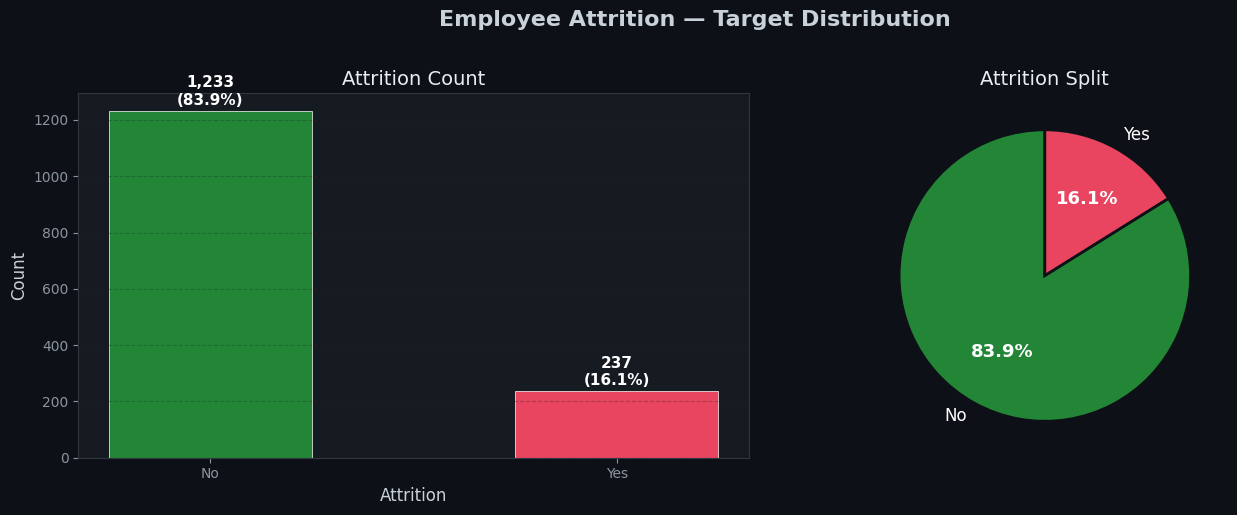


Attrition = No  : 1,233  (83.9%)
Attrition = Yes : 237  (16.1%)
Class Imbalance Ratio : 5.2:1


In [31]:
# ============================================================
# 6.1 TARGET ANALYSIS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Employee Attrition — Target Distribution', fontsize=16, fontweight='bold', y=1.02)

counts = df['Attrition'].value_counts()
colors = [GREEN, RED]

# Count plot
bars = axes[0].bar(counts.index, counts.values, color=colors, width=0.5, edgecolor='white', linewidth=0.5)
axes[0].set_title('Attrition Count', fontsize=14)
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold', color='white')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index, autopct='%1.1f%%',
    colors=colors, startangle=90,
    wedgeprops={'edgecolor': '#0d1117', 'linewidth': 2},
    textprops={'fontsize': 12, 'color': 'white'}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
axes[1].set_title('Attrition Split', fontsize=14)

plt.tight_layout()
plt.savefig('../images/01_target_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'\nAttrition = No  : {counts["No"]:,}  ({counts["No"]/len(df)*100:.1f}%)')
print(f'Attrition = Yes : {counts["Yes"]:,}  ({counts["Yes"]/len(df)*100:.1f}%)')
print(f'Class Imbalance Ratio : {counts["No"]/counts["Yes"]:.1f}:1')


Numerical features: 23


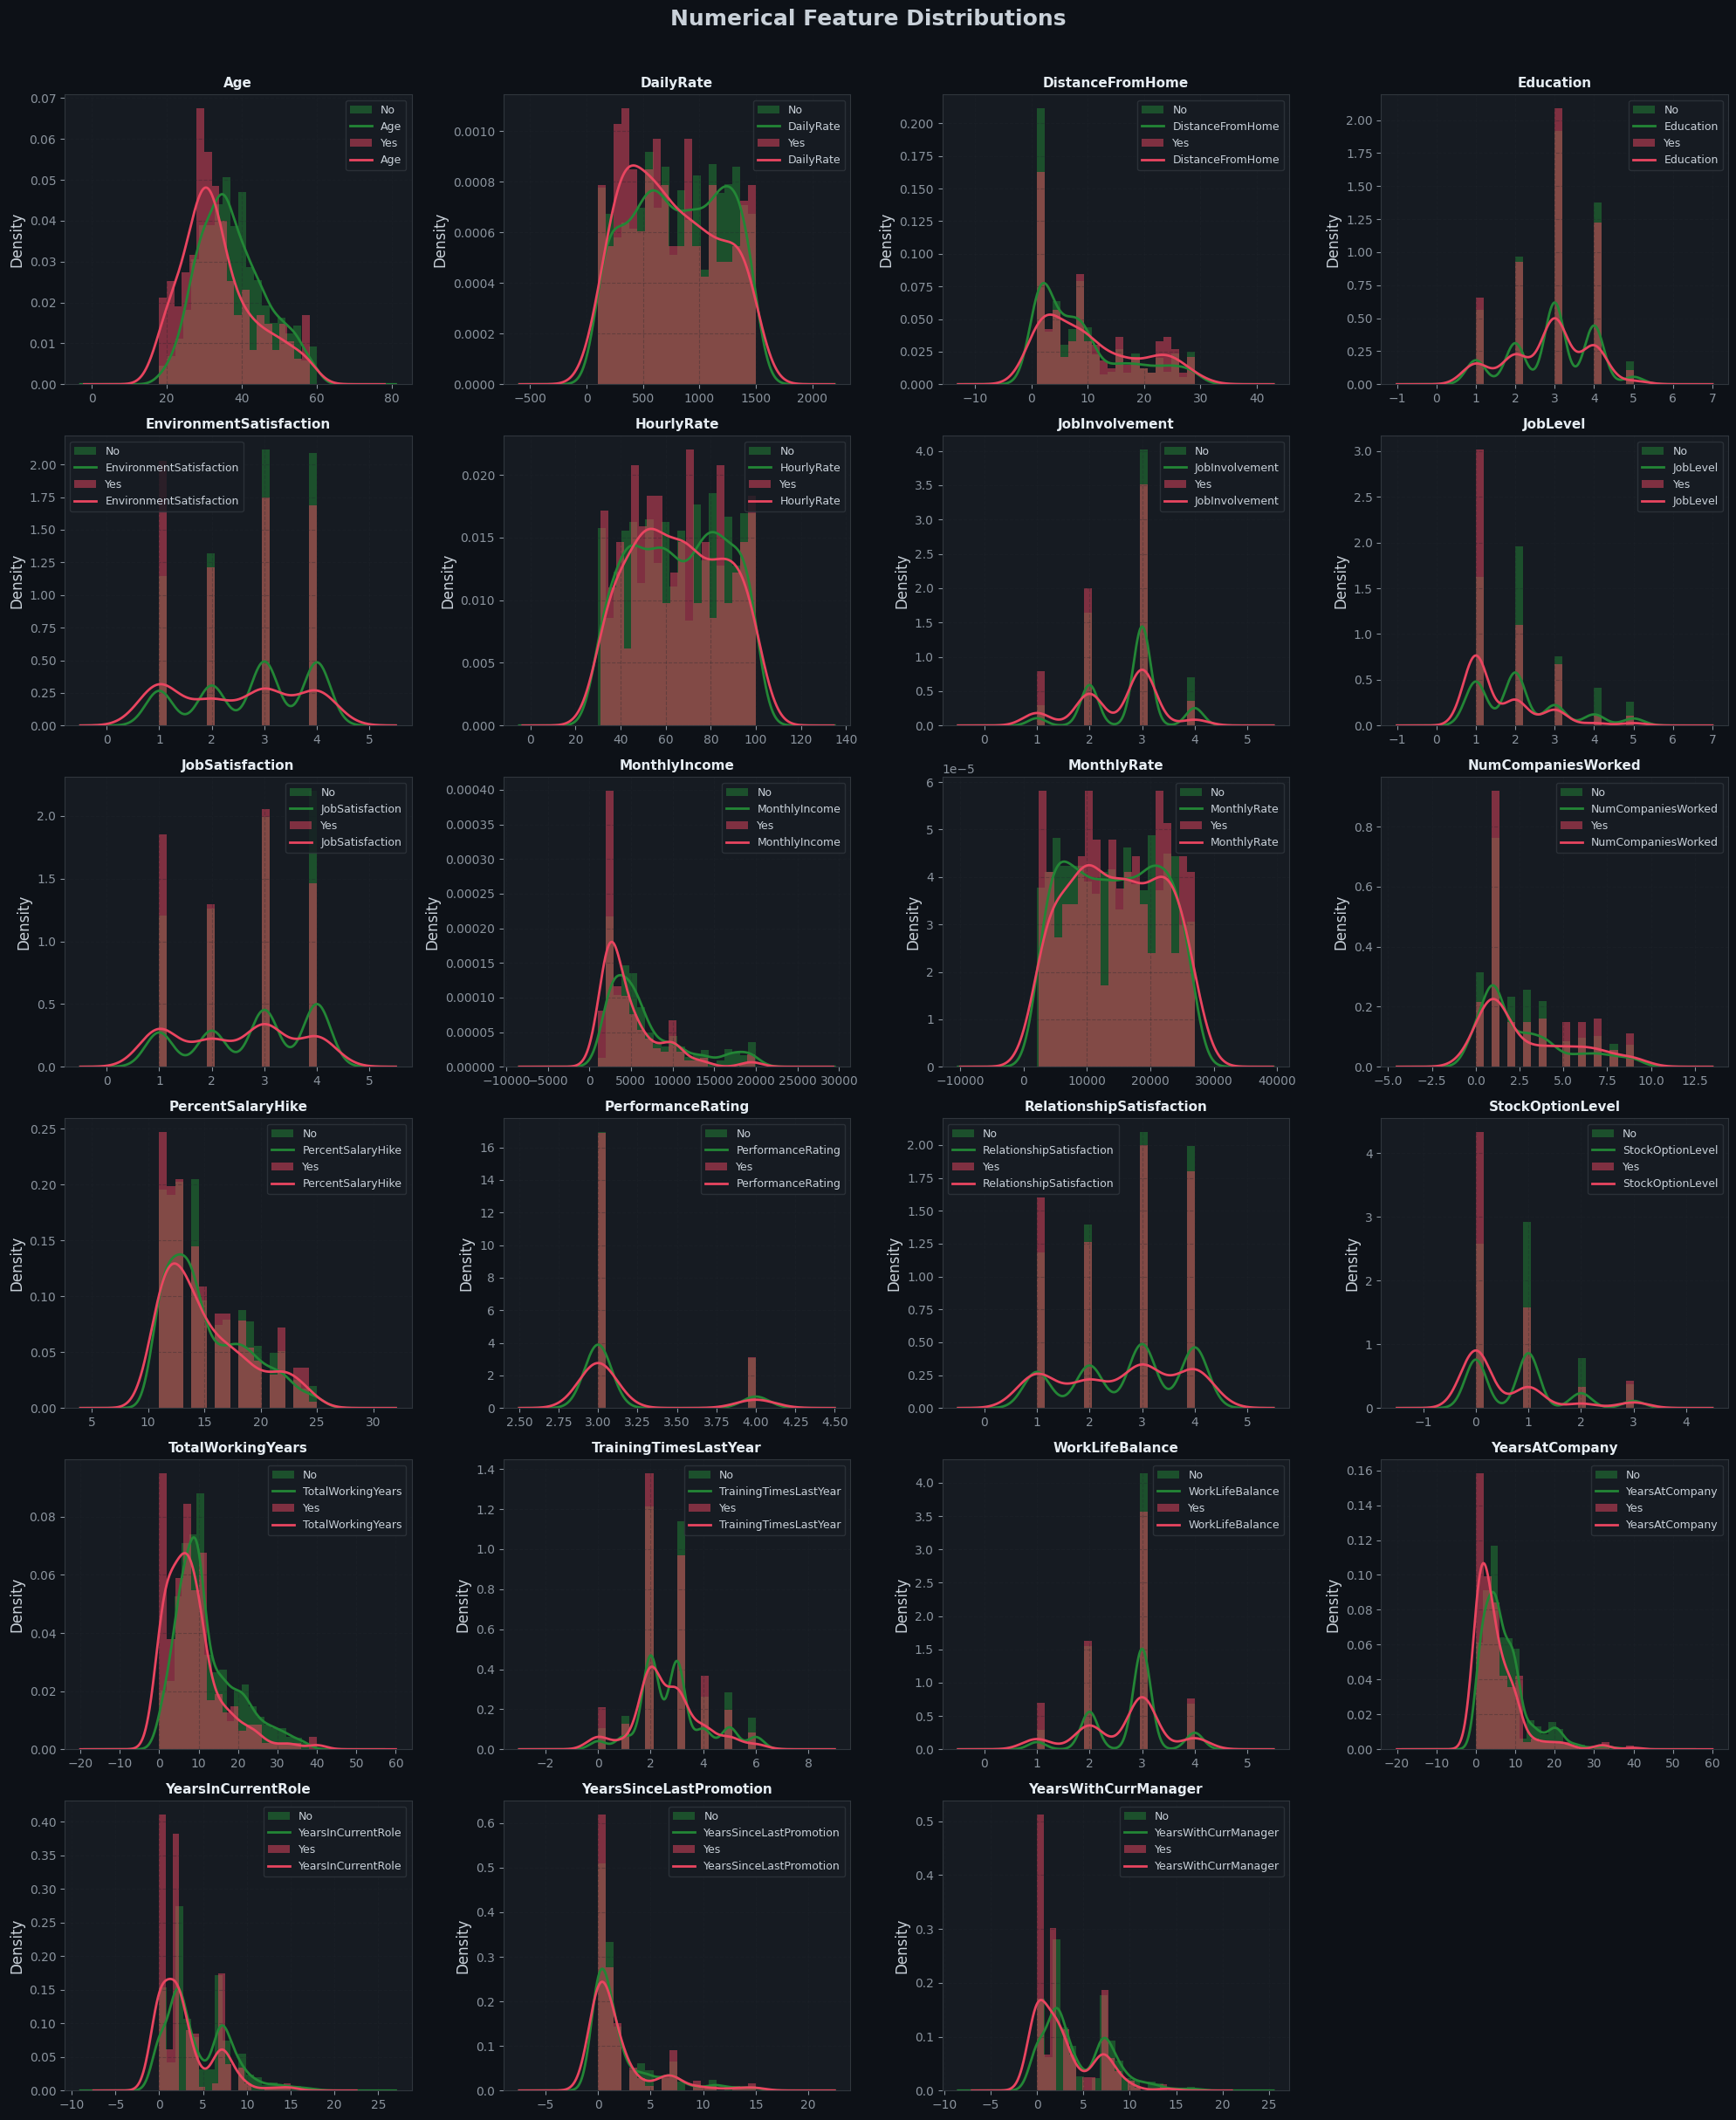

In [32]:
# ============================================================
# 6.2 NUMERICAL FEATURE DISTRIBUTIONS — HISTOGRAMS + KDE
# ============================================================
num_cols = df.select_dtypes(include='number').columns.tolist()
print(f'Numerical features: {len(num_cols)}')

n_cols = 4
n_rows = -(-len(num_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
fig.suptitle('Numerical Feature Distributions', fontsize=18, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    for attrition, color in [('No', GREEN), ('Yes', RED)]:
        subset = df[df['Attrition'] == attrition][col]
        subset.plot.hist(ax=ax, alpha=0.5, color=color, bins=20, label=attrition, density=True)
        subset.plot.kde(ax=ax, color=color, linewidth=2)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../images/02_numerical_distributions.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()


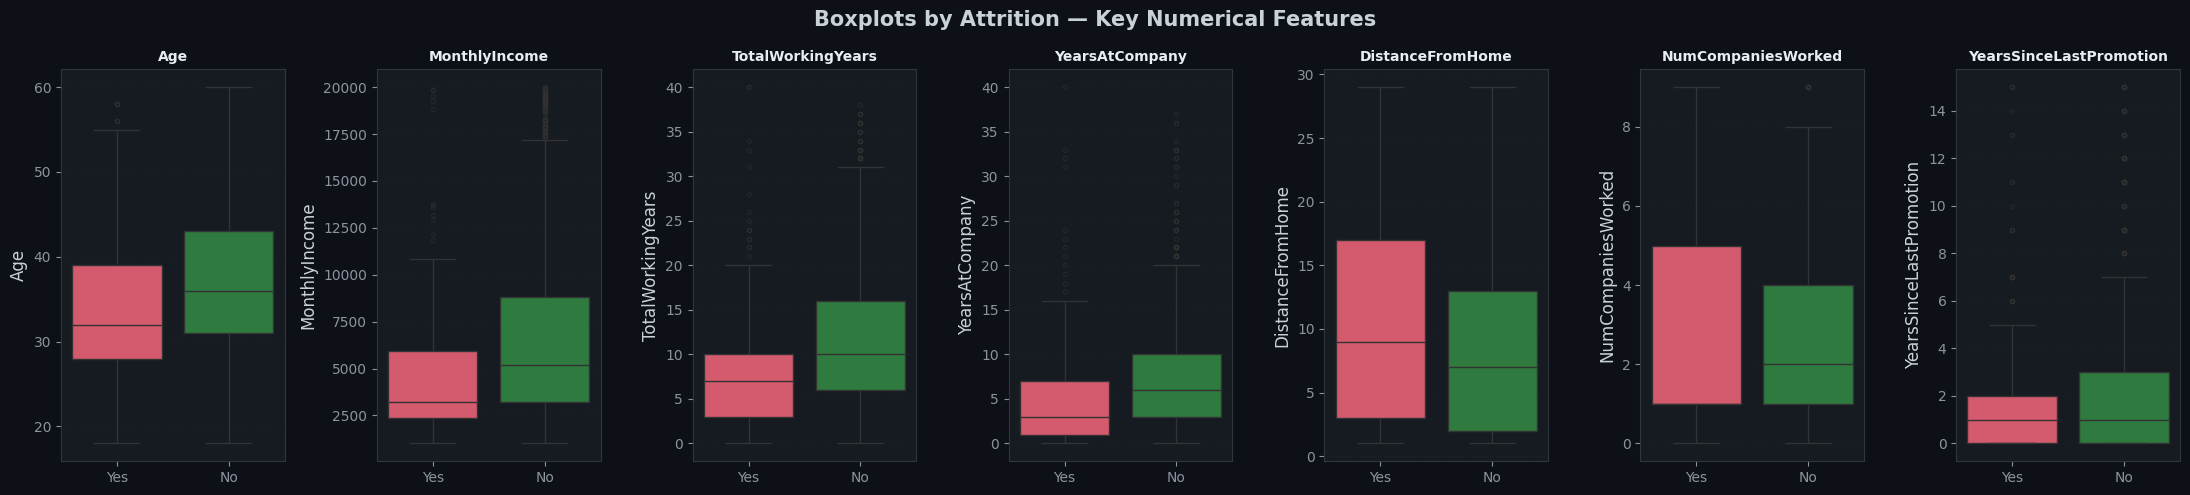

In [33]:
# ============================================================
# 6.3 BOXPLOTS — OUTLIER DETECTION
# ============================================================
key_num = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
           'DistanceFromHome', 'NumCompaniesWorked', 'YearsSinceLastPromotion']

fig, axes = plt.subplots(1, len(key_num), figsize=(22, 5))
fig.suptitle('Boxplots by Attrition — Key Numerical Features', fontsize=15, fontweight='bold')

for i, col in enumerate(key_num):
    sns.boxplot(
        data=df, x='Attrition', y=col, ax=axes[i],
        palette={'No': GREEN, 'Yes': RED},
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4}
    )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/03_boxplots.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()


Categorical features: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


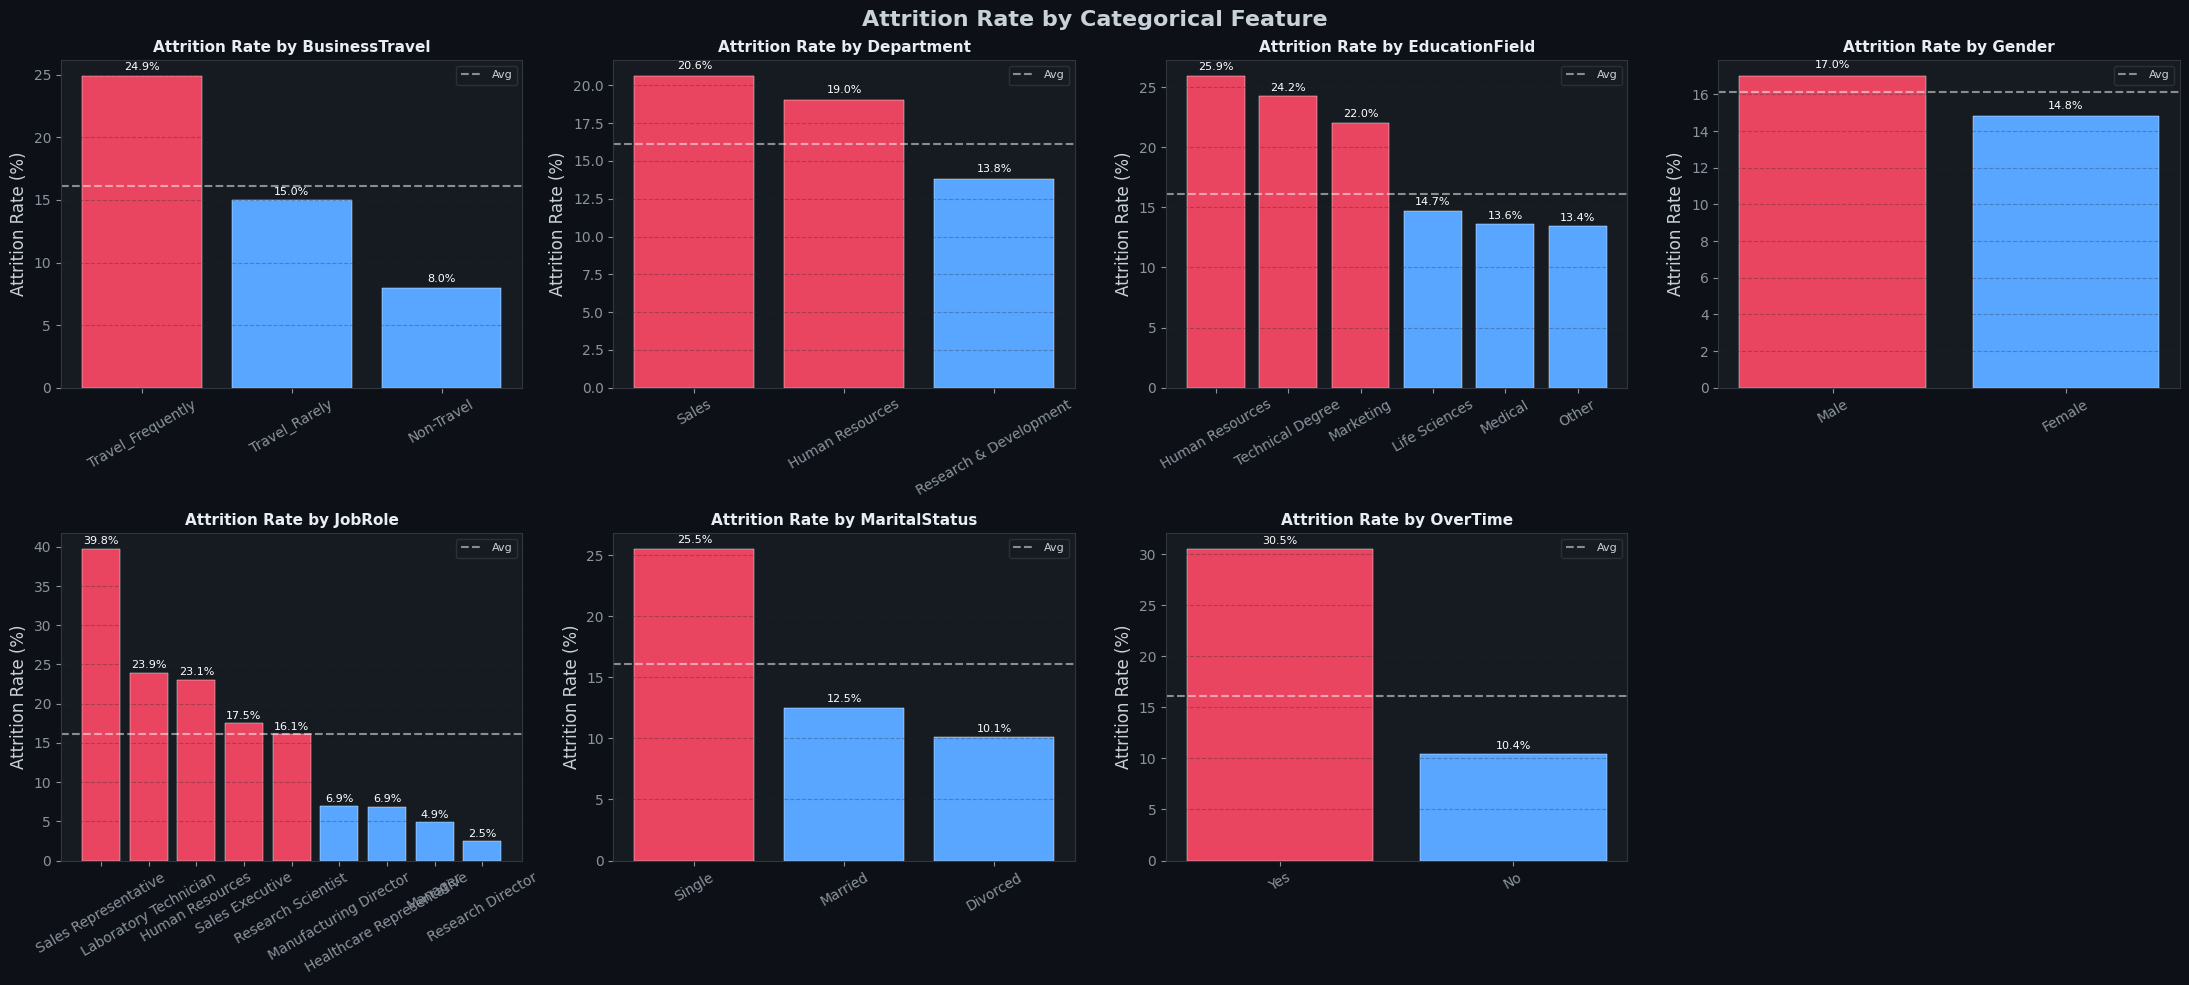

In [34]:
# ============================================================
# 6.4 CATEGORICAL FEATURE ANALYSIS
# ============================================================
cat_cols = df.select_dtypes(include='object').columns.drop('Attrition').tolist()
print(f'Categorical features: {cat_cols}')

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Attrition Rate by Categorical Feature', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    attr_rate = df.groupby(col)['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
    bars = axes[i].bar(attr_rate.index, attr_rate.values,
                       color=[RED if v > 16 else ACCENT for v in attr_rate.values],
                       edgecolor='white', linewidth=0.3)
    axes[i].axhline(df['Attrition'].eq('Yes').mean() * 100, color='white', linestyle='--', alpha=0.5, label='Avg')
    axes[i].set_title(f'Attrition Rate by {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].legend(fontsize=8)
    for bar, val in zip(bars, attr_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=8, color='white')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../images/04_categorical_attrition.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()


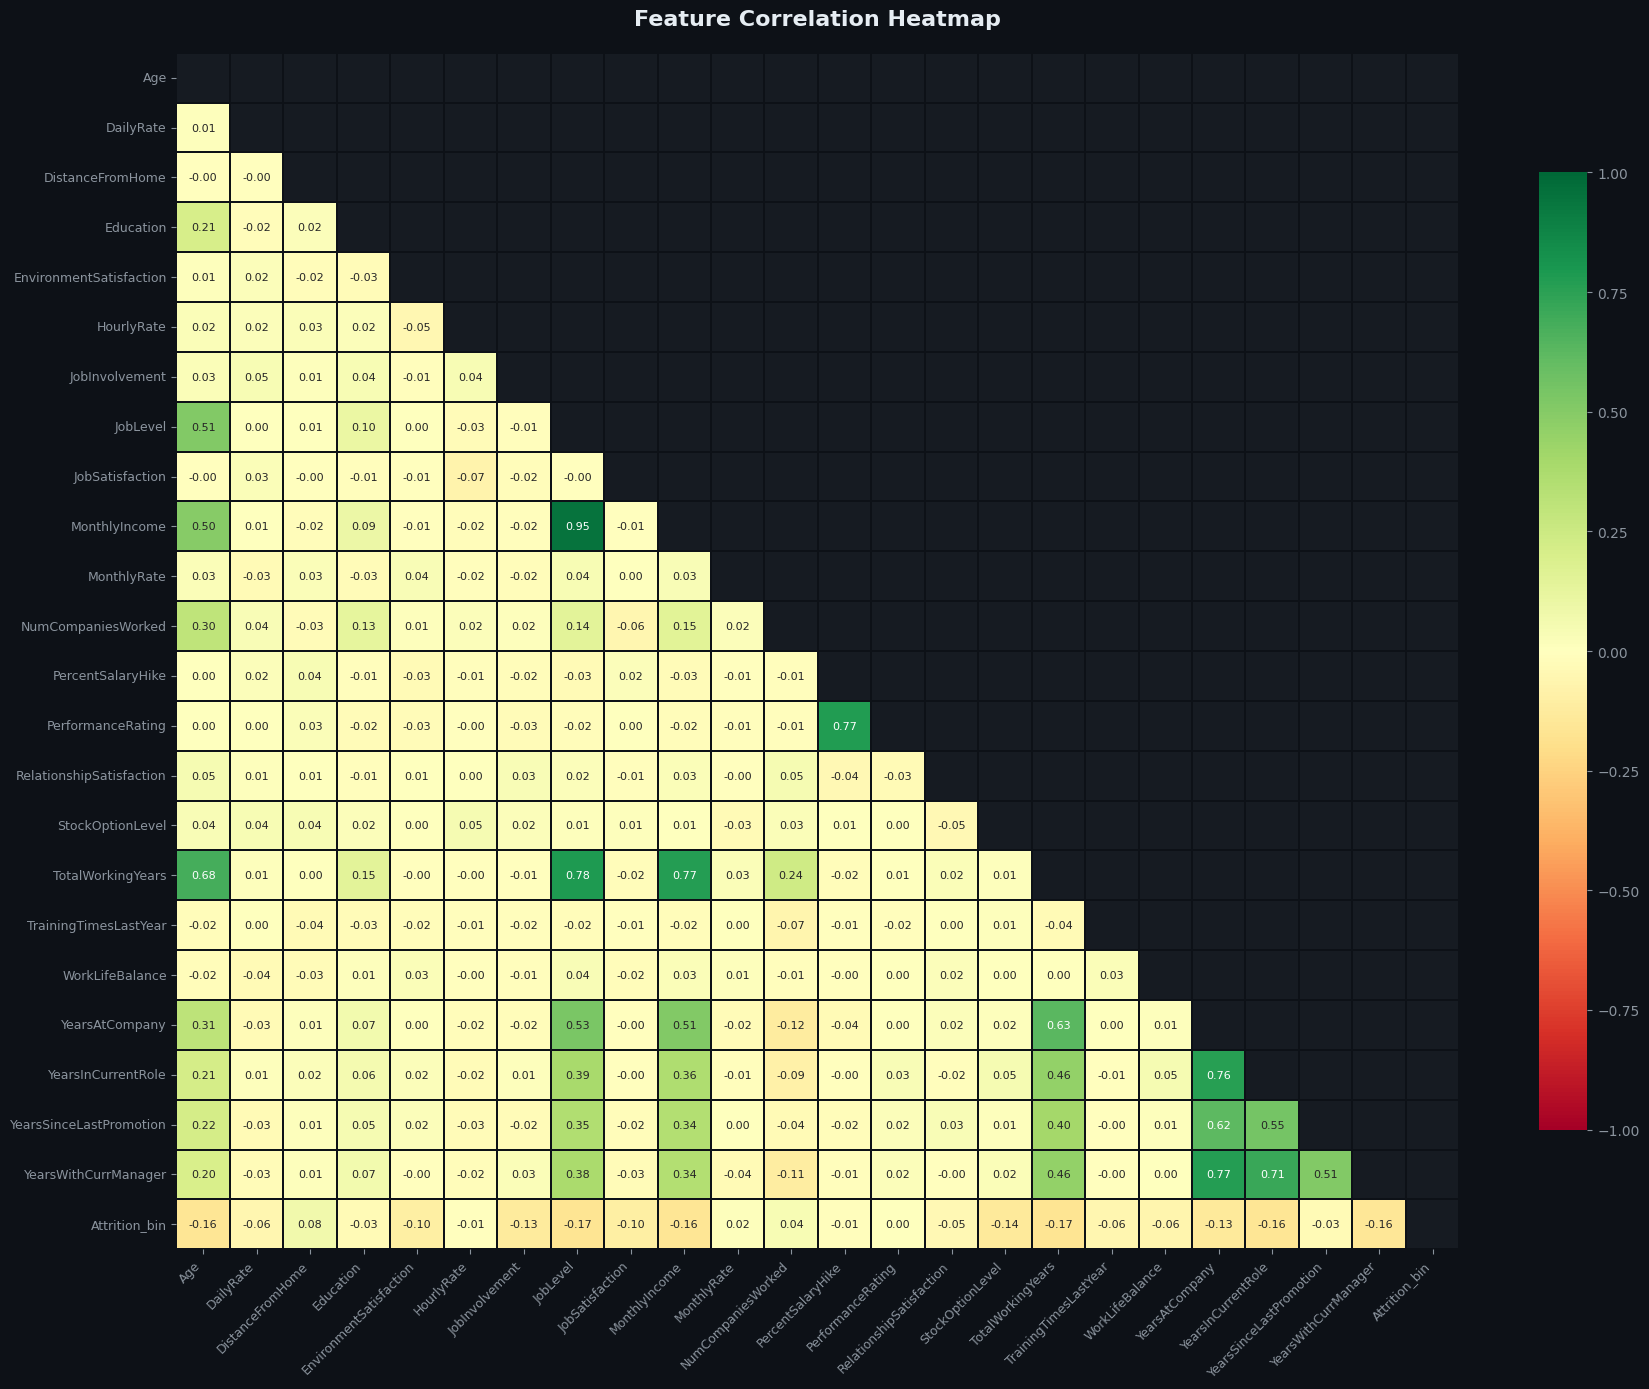

In [35]:
# ============================================================
# 6.5 CORRELATION HEATMAP
# ============================================================
df_corr = df.copy()
df_corr['Attrition_bin'] = (df_corr['Attrition'] == 'Yes').astype(int)
corr = df_corr[num_cols + ['Attrition_bin']].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.3, linecolor='#0d1117',
    annot_kws={'size': 8}, ax=ax, vmin=-1, vmax=1,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('../images/05_correlation_heatmap.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()


In [36]:
# ---- Top correlations with target ----
target_corr = corr['Attrition_bin'].drop('Attrition_bin').sort_values(key=abs, ascending=False)
print('Top 15 Features Correlated with Attrition:')
print(target_corr.head(15).to_string())


Top 15 Features Correlated with Attrition:
TotalWorkingYears         -0.1711
JobLevel                  -0.1691
YearsInCurrentRole        -0.1605
MonthlyIncome             -0.1598
Age                       -0.1592
YearsWithCurrManager      -0.1562
StockOptionLevel          -0.1371
YearsAtCompany            -0.1344
JobInvolvement            -0.1300
JobSatisfaction           -0.1035
EnvironmentSatisfaction   -0.1034
DistanceFromHome           0.0779
WorkLifeBalance           -0.0639
TrainingTimesLastYear     -0.0595
DailyRate                 -0.0567


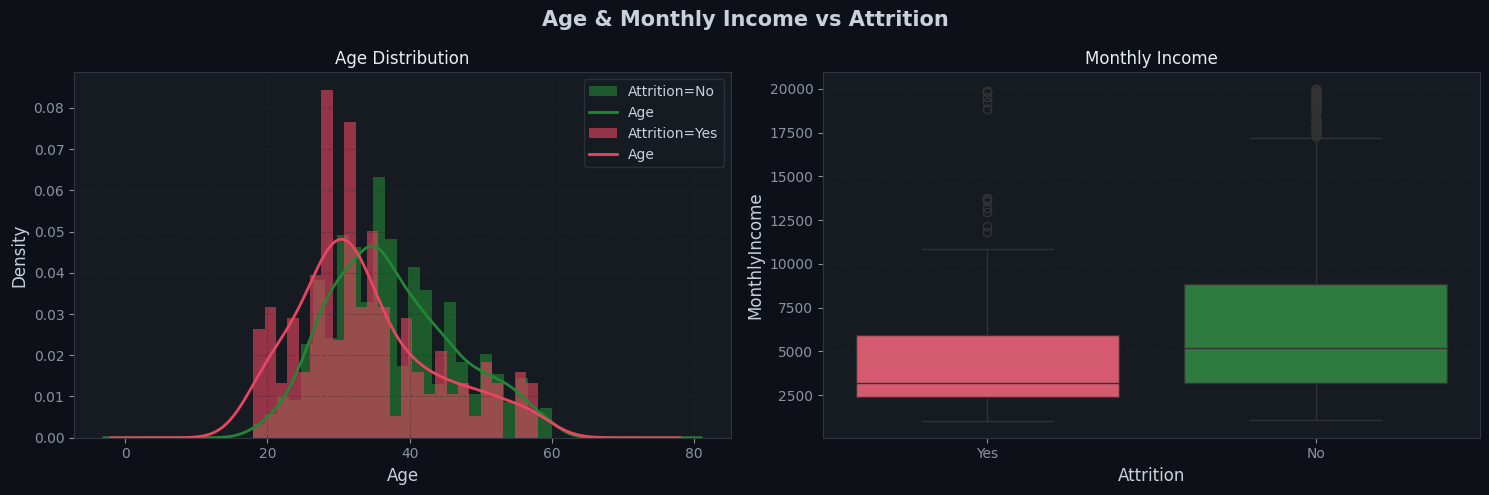

In [37]:
# ============================================================
# 6.6 BIVARIATE ANALYSIS — AGE & MONTHLY INCOME
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Age & Monthly Income vs Attrition', fontsize=15, fontweight='bold')

for attrition, color in [('No', GREEN), ('Yes', RED)]:
    s = df[df['Attrition'] == attrition]
    axes[0].hist(s['Age'], bins=25, alpha=0.6, color=color, label=f'Attrition={attrition}', density=True)
    s['Age'].plot.kde(ax=axes[0], color=color, linewidth=2)

axes[0].set_title('Age Distribution', fontsize=12)
axes[0].set_xlabel('Age')
axes[0].legend()
axes[0].grid(alpha=0.3)

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[1],
            palette={'No': GREEN, 'Yes': RED})
axes[1].set_title('Monthly Income', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/06_age_income_bivariate.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()


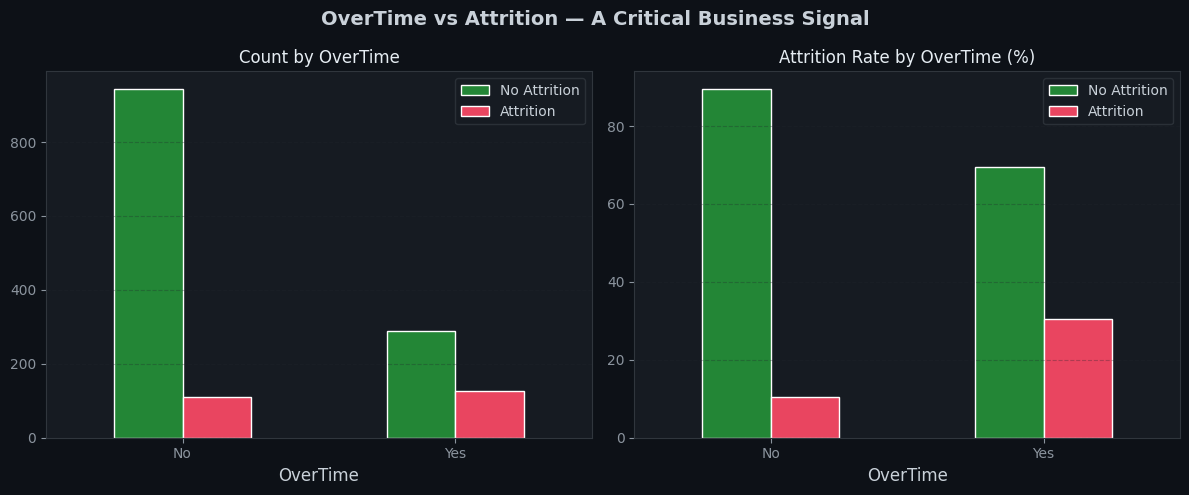

Attrition rates:
OverTime
No    10.4364
Yes   30.5288


In [38]:
# ============================================================
# 6.7 OVERTIME — CRITICAL DRIVER
# ============================================================
ot = df.groupby(['OverTime', 'Attrition']).size().unstack(fill_value=0)
ot_pct = ot.div(ot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('OverTime vs Attrition — A Critical Business Signal', fontsize=14, fontweight='bold')

ot.plot(kind='bar', ax=axes[0], color=[GREEN, RED], edgecolor='white', width=0.5)
axes[0].set_title('Count by OverTime', fontsize=12)
axes[0].set_xlabel('OverTime')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['No Attrition', 'Attrition'])
axes[0].grid(axis='y', alpha=0.3)

ot_pct.plot(kind='bar', ax=axes[1], color=[GREEN, RED], edgecolor='white', width=0.5)
axes[1].set_title('Attrition Rate by OverTime (%)', fontsize=12)
axes[1].set_xlabel('OverTime')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['No Attrition', 'Attrition'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/07_overtime_attrition.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print('Attrition rates:')
print(ot_pct['Yes'].to_string())


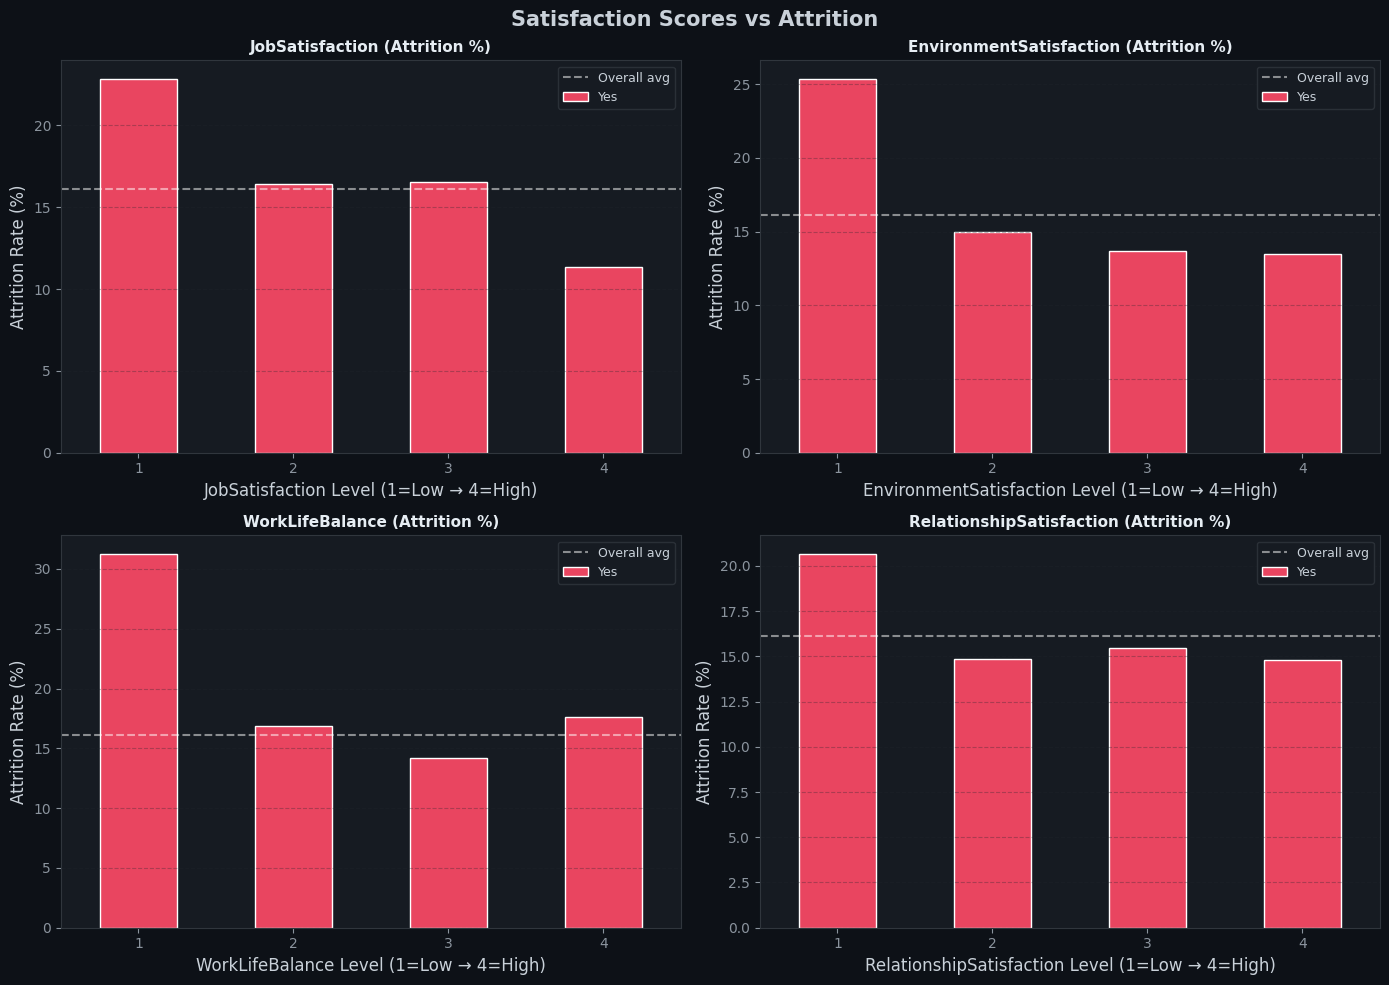

In [39]:
# ============================================================
# 6.8 SATISFACTION SCORES ANALYSIS
# ============================================================
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'RelationshipSatisfaction']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Satisfaction Scores vs Attrition', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(sat_cols):
    pivot = df.groupby([col, 'Attrition']).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    pivot_pct['Yes'].plot(kind='bar', ax=axes[i], color=RED, edgecolor='white', width=0.5)
    axes[i].axhline(df['Attrition'].eq('Yes').mean() * 100, color='white', linestyle='--', alpha=0.5, label='Overall avg')
    axes[i].set_title(f'{col} (Attrition %)', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(f'{col} Level (1=Low → 4=High)')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../images/08_satisfaction_attrition.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()


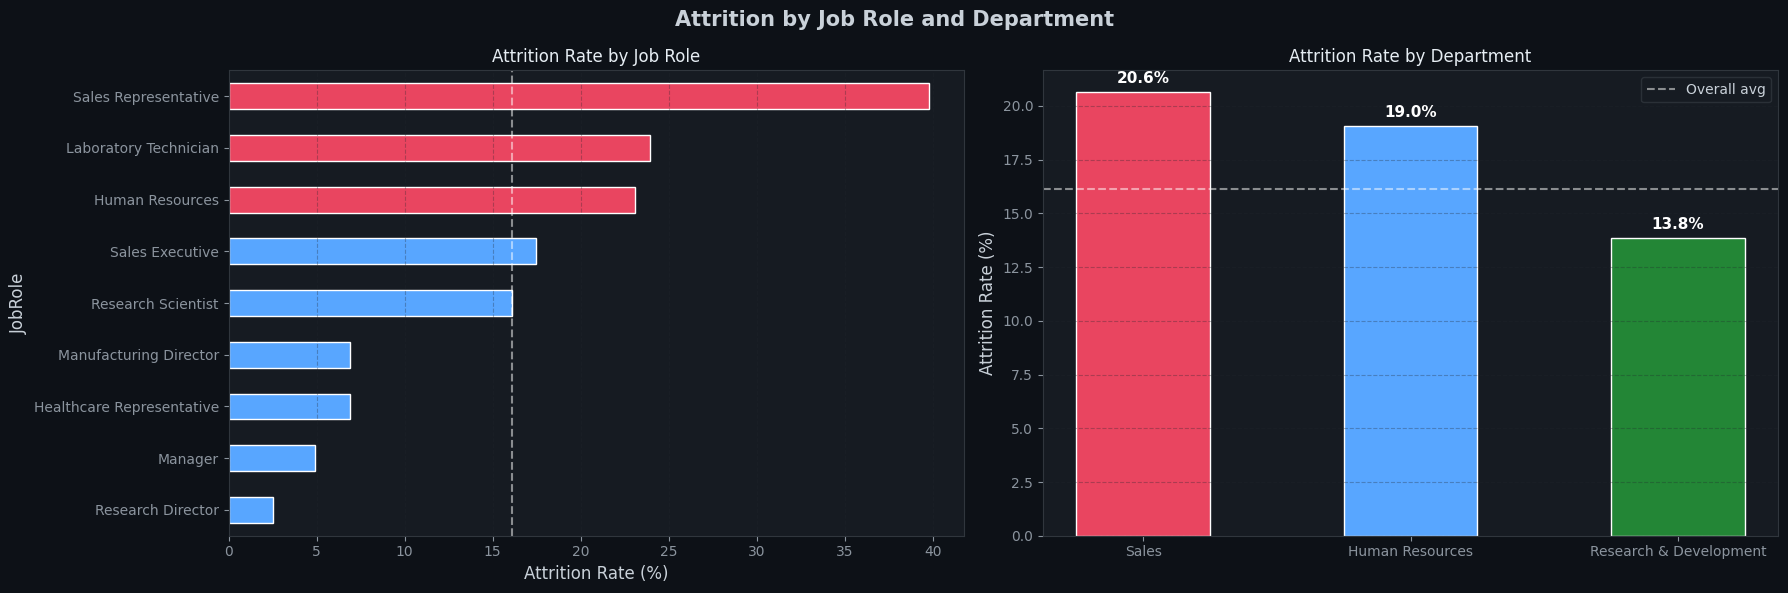

In [40]:
# ============================================================
# 6.9 JOB ROLE & DEPARTMENT ANALYSIS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Attrition by Job Role and Department', fontsize=15, fontweight='bold')

# Job Role
role_attr = df.groupby('JobRole')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=True)
colors_role = [RED if v > 20 else ACCENT for v in role_attr.values]
role_attr.plot(kind='barh', ax=axes[0], color=colors_role, edgecolor='white')
axes[0].axvline(df['Attrition'].eq('Yes').mean() * 100, color='white', linestyle='--', alpha=0.5)
axes[0].set_title('Attrition Rate by Job Role', fontsize=12)
axes[0].set_xlabel('Attrition Rate (%)')
axes[0].grid(axis='x', alpha=0.3)

# Department
dept_attr = df.groupby('Department')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
bars = axes[1].bar(dept_attr.index, dept_attr.values, color=[RED, ACCENT, GREEN], edgecolor='white', width=0.5)
axes[1].axhline(df['Attrition'].eq('Yes').mean() * 100, color='white', linestyle='--', alpha=0.5, label='Overall avg')
axes[1].set_title('Attrition Rate by Department', fontsize=12)
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, dept_attr.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('../images/09_role_dept_attrition.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()


---
# 7. ⚙️ Feature Engineering

## Strategy
1. **Target encode** Attrition: `Yes` → 1, `No` → 0
2. **Binary encode** OverTime: `Yes` → 1, `No` → 0
3. **One-Hot Encode** all remaining categorical features
4. **Ordinal encode** BusinessTravel (ordered)


In [42]:
df_model = df.copy()

# ---- Target Encoding ----
df_model['Attrition'] = df_model['Attrition'].map({'Yes': 1, 'No': 0})

# ---- Binary Encoding ----
df_model['OverTime'] = df_model['OverTime'].map({'Yes': 1, 'No': 0})

# ---- Ordinal Encoding for BusinessTravel ----
travel_map = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
df_model['BusinessTravel'] = df_model['BusinessTravel'].map(travel_map)

# ---- One-Hot Encoding for remaining categoricals ----
remaining_cats = df_model.select_dtypes(include='object').columns.tolist()
print(f'One-Hot Encoding: {remaining_cats}')
df_model = pd.get_dummies(df_model, columns=remaining_cats, drop_first=True)

# ---- Convert bool to int ----
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print(f'\nFinal dataset shape: {df_model.shape}')
print(f'Features          : {df_model.shape[1] - 1}')
print(f'Target            : Attrition')
print(f'\nAttrition value counts:')
print(df_model['Attrition'].value_counts())


One-Hot Encoding: ['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

Final dataset shape: (1470, 44)
Features          : 43
Target            : Attrition

Attrition value counts:
Attrition
0    1233
1     237
Name: count, dtype: int64


---
# 8. ✂️ Train-Test Split



In [43]:
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print('=' * 50)
print('  Train-Test Split (80/20 Stratified)')
print('=' * 50)
print(f'  X_train  : {X_train.shape}')
print(f'  X_test   : {X_test.shape}')
print(f'  y_train  : {Counter(y_train)}')
print(f'  y_test   : {Counter(y_test)}')
print(f'\n  Train Attrition Rate : {y_train.mean()*100:.1f}%')
print(f'  Test  Attrition Rate : {y_test.mean()*100:.1f}%')
print('\n✅ Stratification successful — class ratios preserved.')


  Train-Test Split (80/20 Stratified)
  X_train  : (1176, 43)
  X_test   : (294, 43)
  y_train  : Counter({0: 986, 1: 190})
  y_test   : Counter({0: 247, 1: 47})

  Train Attrition Rate : 16.2%
  Test  Attrition Rate : 16.0%

✅ Stratification successful — class ratios preserved.


---
# 9. 📏 Feature Scaling

Distance-based and regularization-based models (KNN, LR, SVM) require feature scaling. Tree-based models do not. We prepare **two versions** of the data.


In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ StandardScaler applied.')
print(f'   Train mean (post-scale): {X_train_scaled.mean():.4f}  (should ≈ 0)')
print(f'   Train std  (post-scale): {X_train_scaled.std():.4f}  (should ≈ 1)')


✅ StandardScaler applied.
   Train mean (post-scale): -0.0000  (should ≈ 0)
   Train std  (post-scale): 1.0000  (should ≈ 1)


---
# 10. 🤖 Machine Learning Models

We train **9 classification models** spanning linear, probabilistic, instance-based, tree, ensemble, and boosting paradigms.


In [45]:
# ============================================================
# HELPER — Evaluate Any Model
# ============================================================
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, needs_proba=True):
    """Train a model and return a metrics dictionary."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    if needs_proba and hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_te)
    else:
        y_prob = y_pred

    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall'   : recall_score(y_te, y_pred, zero_division=0),
        'F1'       : f1_score(y_te, y_pred, zero_division=0),
        'ROC_AUC'  : roc_auc_score(y_te, y_prob),
        'model_obj': model,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }


# ============================================================
# PLOT CONFUSION MATRIX + ROC FOR ONE MODEL
# ============================================================
def plot_model_diagnostics(result, y_te, figsize=(12, 4)):
    name   = result['Model']
    y_pred = result['y_pred']
    y_prob = result['y_prob']

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(f'{name} — Model Diagnostics', fontsize=13, fontweight='bold')

    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Pred No', 'Pred Yes'],
                yticklabels=['True No', 'True Yes'],
                linewidths=1, linecolor='#0d1117')
    axes[0].set_title('Confusion Matrix')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    auc = roc_auc_score(y_te, y_prob)
    axes[1].plot(fpr, tpr, color=ACCENT, linewidth=2, label=f'AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'w--', linewidth=1)
    axes[1].fill_between(fpr, tpr, alpha=0.1, color=ACCENT)
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

print('✅ Helper functions defined.')


✅ Helper functions defined.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL 1: Logistic Regression
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              precision    recall  f1-score   support

        Stay       0.92      0.79      0.85       247
       Leave       0.37      0.66      0.47        47

    accuracy                           0.77       294
   macro avg       0.65      0.72      0.66       294
weighted avg       0.84      0.77      0.79       294



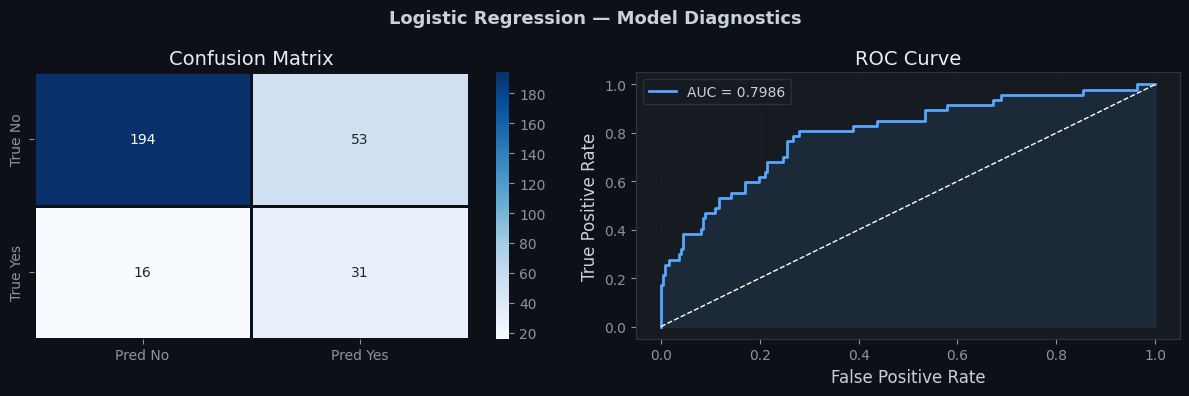

In [46]:
# ============================================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================================
print('━' * 50)
print('  MODEL 1: Logistic Regression')
print('━' * 50)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
result_lr = evaluate_model('Logistic Regression', lr, X_train_scaled, y_train, X_test_scaled, y_test)

print(classification_report(y_test, result_lr['y_pred'], target_names=['Stay', 'Leave']))
plot_model_diagnostics(result_lr, y_test)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL 2: K-Nearest Neighbors
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              precision    recall  f1-score   support

        Stay       0.85      1.00      0.92       247
       Leave       0.83      0.11      0.19        47

    accuracy                           0.85       294
   macro avg       0.84      0.55      0.55       294
weighted avg       0.85      0.85      0.80       294



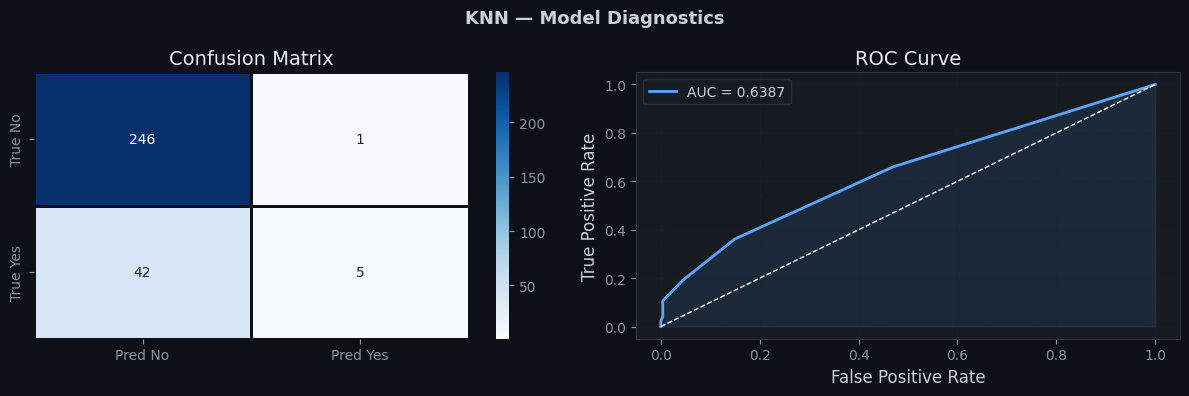

In [47]:
# ============================================================
# MODEL 2: K-NEAREST NEIGHBORS
# ============================================================
print('━' * 50)
print('  MODEL 2: K-Nearest Neighbors')
print('━' * 50)

knn = KNeighborsClassifier(n_neighbors=7)
result_knn = evaluate_model('KNN', knn, X_train_scaled, y_train, X_test_scaled, y_test)

print(classification_report(y_test, result_knn['y_pred'], target_names=['Stay', 'Leave']))
plot_model_diagnostics(result_knn, y_test)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL 3: Gaussian Naive Bayes
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              precision    recall  f1-score   support

        Stay       0.91      0.61      0.73       247
       Leave       0.25      0.70      0.37        47

    accuracy                           0.62       294
   macro avg       0.58      0.65      0.55       294
weighted avg       0.81      0.62      0.67       294



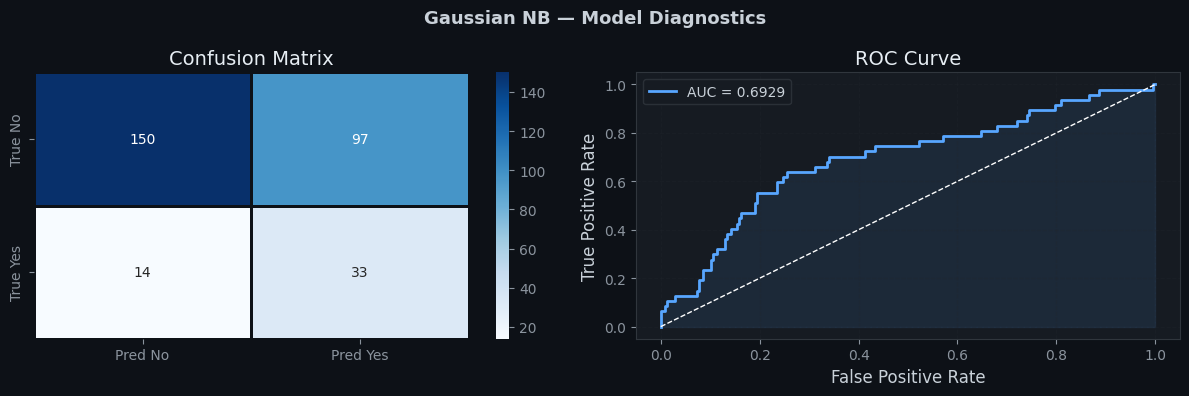

In [48]:
# ============================================================
# MODEL 3: GAUSSIAN NAIVE BAYES
# ============================================================
print('━' * 50)
print('  MODEL 3: Gaussian Naive Bayes')
print('━' * 50)

gnb = GaussianNB()
result_gnb = evaluate_model('Gaussian NB', gnb, X_train_scaled, y_train, X_test_scaled, y_test)

print(classification_report(y_test, result_gnb['y_pred'], target_names=['Stay', 'Leave']))
plot_model_diagnostics(result_gnb, y_test)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL 4: Decision Tree
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              precision    recall  f1-score   support

        Stay       0.90      0.80      0.85       247
       Leave       0.35      0.55      0.43        47

    accuracy                           0.76       294
   macro avg       0.63      0.68      0.64       294
weighted avg       0.81      0.76      0.78       294



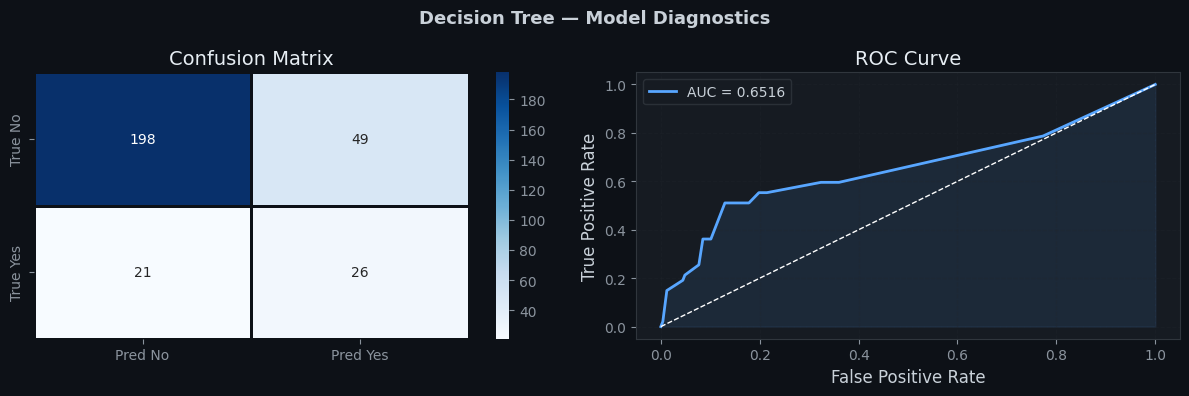

In [49]:
# ============================================================
# MODEL 4: DECISION TREE
# ============================================================
print('━' * 50)
print('  MODEL 4: Decision Tree')
print('━' * 50)

dt = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=RANDOM_STATE)
result_dt = evaluate_model('Decision Tree', dt, X_train, y_train, X_test, y_test)

print(classification_report(y_test, result_dt['y_pred'], target_names=['Stay', 'Leave']))
plot_model_diagnostics(result_dt, y_test)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL 5: Random Forest
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              precision    recall  f1-score   support

        Stay       0.85      0.98      0.91       247
       Leave       0.50      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.53       294
weighted avg       0.79      0.84      0.79       294



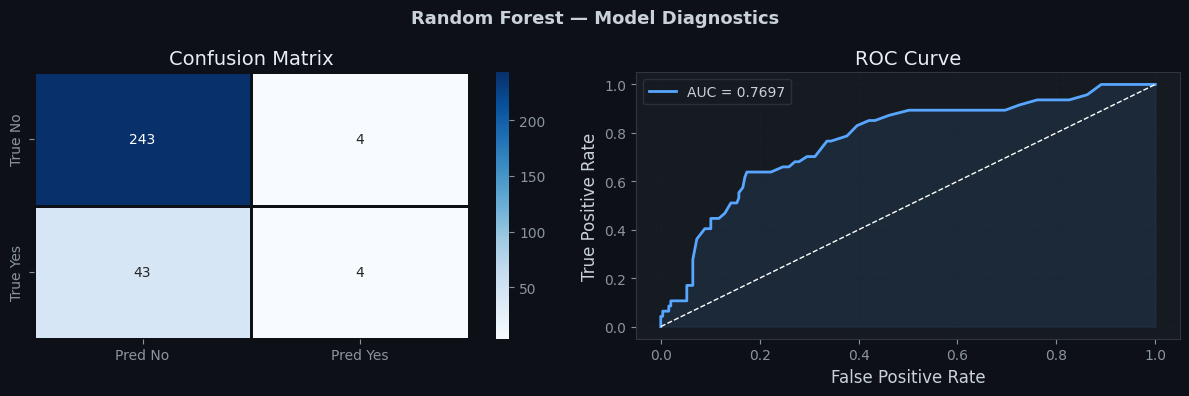

In [50]:
# ============================================================
# MODEL 5: RANDOM FOREST
# ============================================================
print('━' * 50)
print('  MODEL 5: Random Forest')
print('━' * 50)

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
result_rf = evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test)

print(classification_report(y_test, result_rf['y_pred'], target_names=['Stay', 'Leave']))
plot_model_diagnostics(result_rf, y_test)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL 6: AdaBoost
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              precision    recall  f1-score   support

        Stay       0.85      0.99      0.92       247
       Leave       0.67      0.09      0.15        47

    accuracy                           0.85       294
   macro avg       0.76      0.54      0.53       294
weighted avg       0.82      0.85      0.79       294



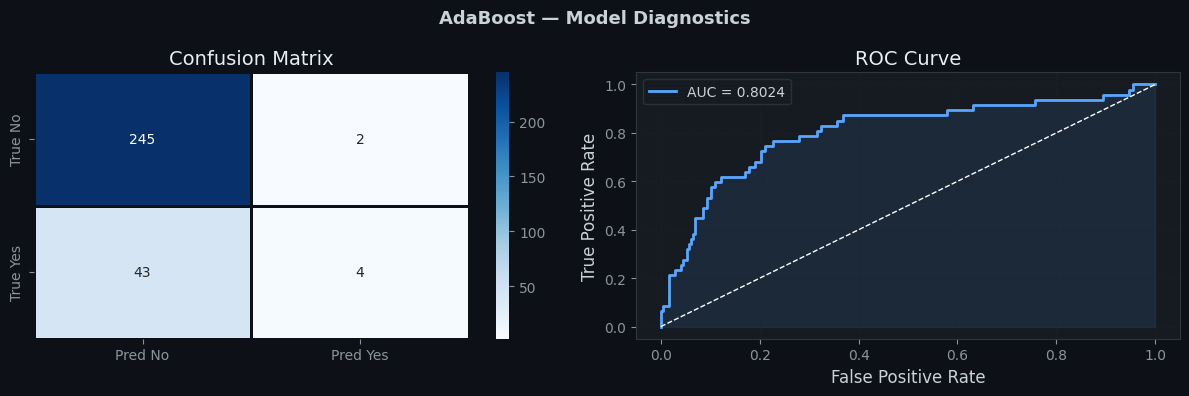

In [51]:
# ============================================================
# MODEL 6: ADABOOST
# ============================================================
print('━' * 50)
print('  MODEL 6: AdaBoost')
print('━' * 50)

ada = AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=RANDOM_STATE)
result_ada = evaluate_model('AdaBoost', ada, X_train, y_train, X_test, y_test)

print(classification_report(y_test, result_ada['y_pred'], target_names=['Stay', 'Leave']))
plot_model_diagnostics(result_ada, y_test)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL 7: Gradient Boosting
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              precision    recall  f1-score   support

        Stay       0.87      0.97      0.92       247
       Leave       0.61      0.23      0.34        47

    accuracy                           0.85       294
   macro avg       0.74      0.60      0.63       294
weighted avg       0.83      0.85      0.83       294



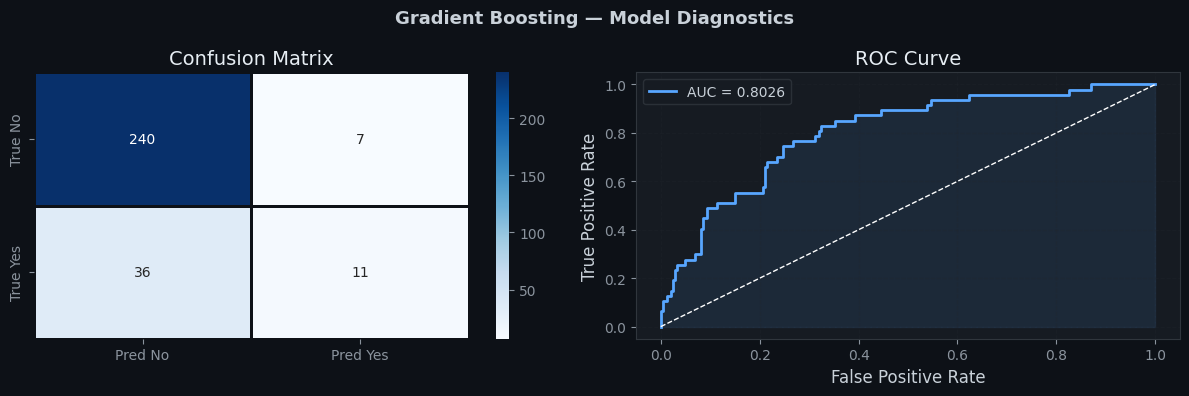

In [52]:
# ============================================================
# MODEL 7: GRADIENT BOOSTING
# ============================================================
print('━' * 50)
print('  MODEL 7: Gradient Boosting')
print('━' * 50)

gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=RANDOM_STATE)
result_gb = evaluate_model('Gradient Boosting', gb, X_train, y_train, X_test, y_test)

print(classification_report(y_test, result_gb['y_pred'], target_names=['Stay', 'Leave']))
plot_model_diagnostics(result_gb, y_test)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL 8: Support Vector Machine
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              precision    recall  f1-score   support

        Stay       0.91      0.88      0.89       247
       Leave       0.45      0.53      0.49        47

    accuracy                           0.82       294
   macro avg       0.68      0.71      0.69       294
weighted avg       0.84      0.82      0.83       294



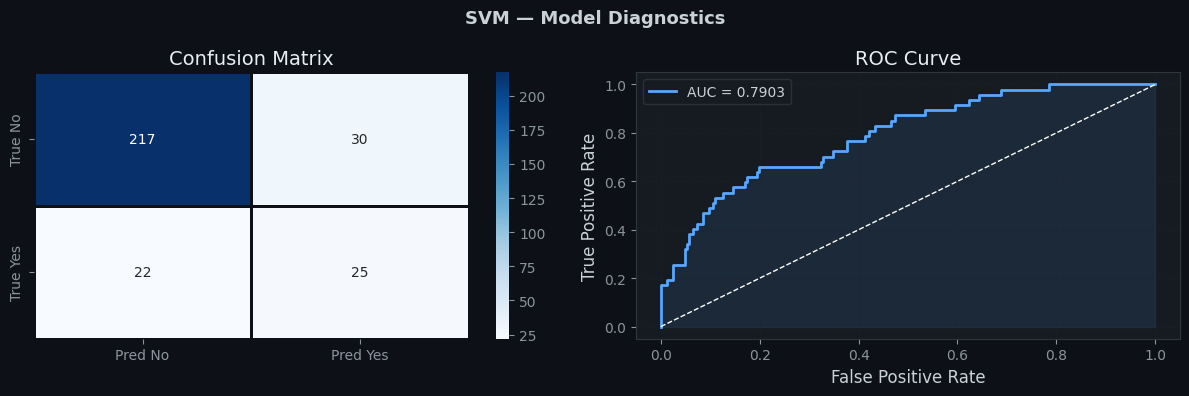

In [53]:
# ============================================================
# MODEL 8: SUPPORT VECTOR MACHINE
# ============================================================
print('━' * 50)
print('  MODEL 8: Support Vector Machine')
print('━' * 50)

svm = SVC(probability=True, class_weight='balanced', kernel='rbf', C=1.0, random_state=RANDOM_STATE)
result_svm = evaluate_model('SVM', svm, X_train_scaled, y_train, X_test_scaled, y_test)

print(classification_report(y_test, result_svm['y_pred'], target_names=['Stay', 'Leave']))
plot_model_diagnostics(result_svm, y_test)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL 9: XGBoost
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              precision    recall  f1-score   support

        Stay       0.89      0.92      0.91       247
       Leave       0.50      0.40      0.45        47

    accuracy                           0.84       294
   macro avg       0.70      0.66      0.68       294
weighted avg       0.83      0.84      0.83       294



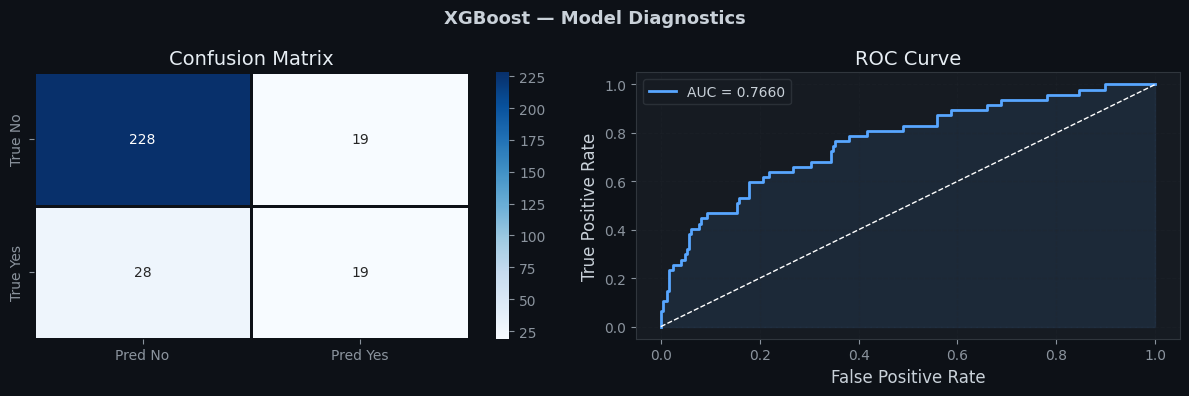

In [54]:
# ============================================================
# MODEL 9: XGBOOST
# ============================================================
print('━' * 50)
print('  MODEL 9: XGBoost')
print('━' * 50)

scale_pos_weight = Counter(y_train)[0] / Counter(y_train)[1]
xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False, eval_metric='logloss',
    random_state=RANDOM_STATE, n_jobs=-1
)
result_xgb = evaluate_model('XGBoost', xgb, X_train, y_train, X_test, y_test)

print(classification_report(y_test, result_xgb['y_pred'], target_names=['Stay', 'Leave']))
plot_model_diagnostics(result_xgb, y_test)


---
# 11. 🎛️ Hyperparameter Tuning

We tune the top 3 models: **Random Forest**, **XGBoost**, and **SVM** using `RandomizedSearchCV` with 5-fold cross-validation and F1 as the scoring metric.


In [55]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ============================================================
# TUNE — RANDOM FOREST
# ============================================================
print('🔍 Tuning Random Forest...')
rf_param_grid = {
    'n_estimators'      : [100, 200, 300, 500],
    'max_depth'         : [None, 6, 10, 15],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2'],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_grid, n_iter=30, scoring='f1', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
result_rf_tuned = evaluate_model('Random Forest (Tuned)', best_rf, X_train, y_train, X_test, y_test)
print(f'  Best params : {rf_search.best_params_}')
print(f'  CV F1 score : {rf_search.best_score_:.4f}')
print(f'  Test F1     : {result_rf_tuned["F1"]:.4f}')


🔍 Tuning Random Forest...
  Best params : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 6}
  CV F1 score : 0.4607
  Test F1     : 0.4146


In [56]:
# ============================================================
# TUNE — XGBOOST
# ============================================================
print('🔍 Tuning XGBoost...')
xgb_param_grid = {
    'n_estimators'  : [200, 300, 500],
    'max_depth'     : [3, 4, 5, 6],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'subsample'     : [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha'     : [0, 0.1, 0.5],
    'reg_lambda'    : [1, 1.5, 2],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, use_label_encoder=False,
                  eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
    xgb_param_grid, n_iter=30, scoring='f1', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
result_xgb_tuned = evaluate_model('XGBoost (Tuned)', best_xgb, X_train, y_train, X_test, y_test)
print(f'  Best params : {xgb_search.best_params_}')
print(f'  CV F1 score : {xgb_search.best_score_:.4f}')
print(f'  Test F1     : {result_xgb_tuned["F1"]:.4f}')


🔍 Tuning XGBoost...
  Best params : {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
  CV F1 score : 0.5606
  Test F1     : 0.4299


In [57]:
# ============================================================
# TUNE — SVM
# ============================================================
print('🔍 Tuning SVM...')
svm_param_grid = {
    'C'      : [0.01, 0.1, 1, 5, 10],
    'kernel' : ['rbf', 'linear'],
    'gamma'  : ['scale', 'auto'],
}

svm_search = GridSearchCV(
    SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    svm_param_grid, scoring='f1', cv=cv, n_jobs=-1, verbose=0
)
svm_search.fit(X_train_scaled, y_train)

best_svm = svm_search.best_estimator_
result_svm_tuned = evaluate_model('SVM (Tuned)', best_svm, X_train_scaled, y_train, X_test_scaled, y_test)
print(f'  Best params : {svm_search.best_params_}')
print(f'  CV F1 score : {svm_search.best_score_:.4f}')
print(f'  Test F1     : {result_svm_tuned["F1"]:.4f}')


🔍 Tuning SVM...
  Best params : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
  CV F1 score : 0.5477
  Test F1     : 0.4902


---
# 12. 📈 Model Evaluation



In [58]:
# ---- Compile all results ----
all_results = [
    result_lr, result_knn, result_gnb, result_dt,
    result_rf, result_ada, result_gb, result_svm, result_xgb,
    result_rf_tuned, result_xgb_tuned, result_svm_tuned
]

metrics_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
leaderboard = pd.DataFrame([{k: r[k] for k in metrics_cols} for r in all_results])
leaderboard = leaderboard.sort_values('F1', ascending=False).reset_index(drop=True)
leaderboard.index += 1

print('=' * 80)
print('  MODEL LEADERBOARD — Ranked by F1 Score')
print('=' * 80)
print(leaderboard.to_string())


  MODEL LEADERBOARD — Ranked by F1 Score
                    Model  Accuracy  Precision  Recall     F1  ROC_AUC
1             SVM (Tuned)    0.8231     0.4545  0.5319 0.4902   0.7903
2                     SVM    0.8231     0.4545  0.5319 0.4902   0.7903
3     Logistic Regression    0.7653     0.3690  0.6596 0.4733   0.7986
4                 XGBoost    0.8401     0.5000  0.4043 0.4471   0.7660
5         XGBoost (Tuned)    0.7925     0.3833  0.4894 0.4299   0.7903
6           Decision Tree    0.7619     0.3467  0.5532 0.4262   0.6516
7   Random Forest (Tuned)    0.8367     0.4857  0.3617 0.4146   0.7777
8             Gaussian NB    0.6224     0.2538  0.7021 0.3729   0.6929
9       Gradient Boosting    0.8537     0.6111  0.2340 0.3385   0.8026
10                    KNN    0.8537     0.8333  0.1064 0.1887   0.6387
11               AdaBoost    0.8469     0.6667  0.0851 0.1509   0.8024
12          Random Forest    0.8401     0.5000  0.0851 0.1455   0.7697


---
# 13. 🏆 Advanced Model Comparison


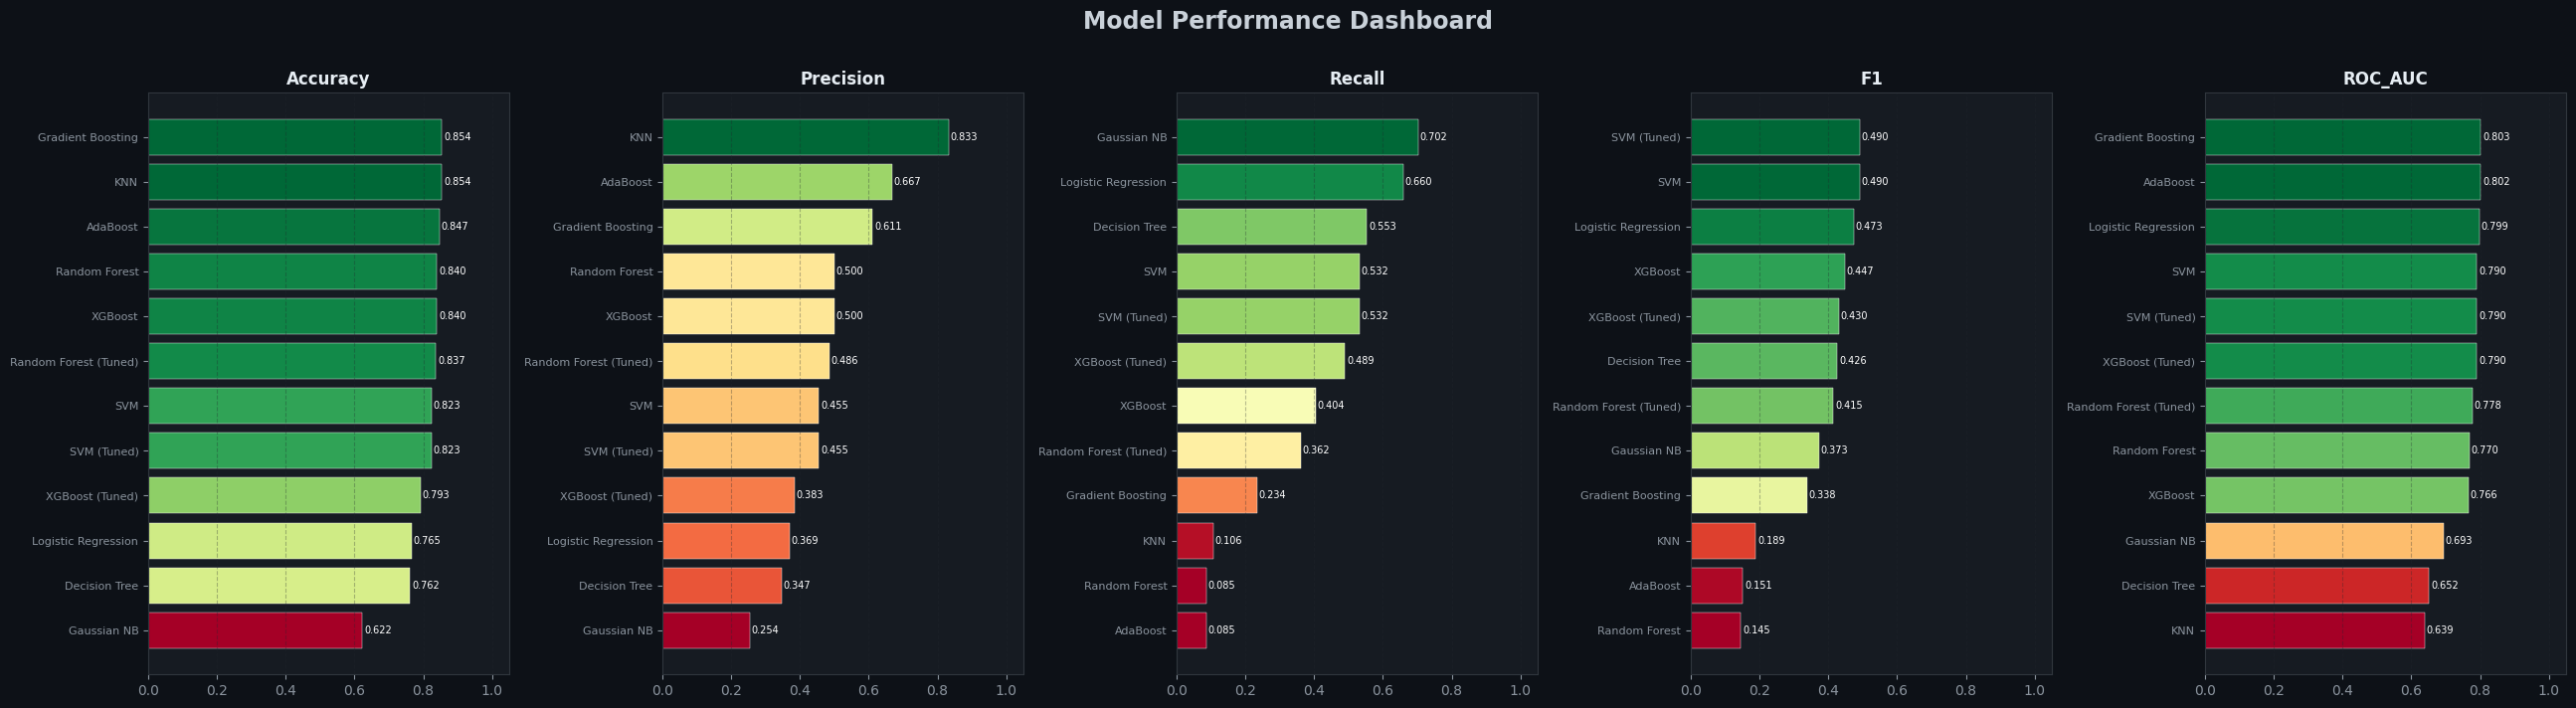

In [59]:
# ============================================================
# PERFORMANCE DASHBOARD
# ============================================================
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
lb = leaderboard.set_index('Model')[metrics_to_plot]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(26, 7))
fig.suptitle('Model Performance Dashboard', fontsize=17, fontweight='bold', y=1.01)

cmap = plt.cm.RdYlGn
for i, metric in enumerate(metrics_to_plot):
    vals = lb[metric].values
    sorted_idx = np.argsort(vals)
    colors = [cmap(v) for v in (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)]
    sorted_colors = [colors[j] for j in sorted_idx]
    sorted_models = [lb.index[j] for j in sorted_idx]
    sorted_vals   = [vals[j] for j in sorted_idx]

    bars = axes[i].barh(sorted_models, sorted_vals, color=sorted_colors, edgecolor='white', linewidth=0.3)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_xlim(0, 1.05)
    axes[i].tick_params(axis='y', labelsize=8)
    axes[i].grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, sorted_vals):
        axes[i].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=7, color='white')

plt.tight_layout()
plt.savefig('../images/11_model_comparison_dashboard.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()


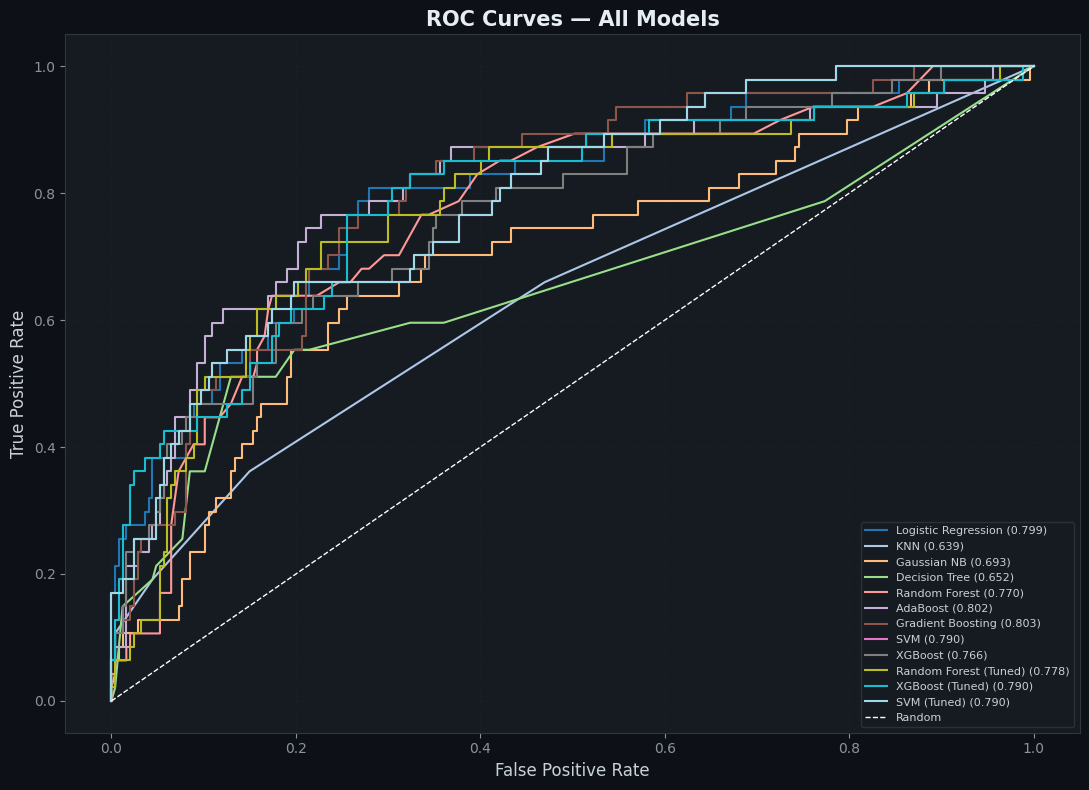

In [60]:
# ---- ROC Curves — All Models ----
fig, ax = plt.subplots(figsize=(11, 8))
ax.set_title('ROC Curves — All Models', fontsize=15, fontweight='bold')

colors_roc = plt.cm.tab20(np.linspace(0, 1, len(all_results)))

for r, c in zip(all_results, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    auc = roc_auc_score(y_test, r['y_prob'])
    ax.plot(fpr, tpr, color=c, linewidth=1.5, label=f"{r['Model']} ({auc:.3f})")

ax.plot([0, 1], [0, 1], 'w--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/12_roc_curves_all.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()


---
# 14. 🥇 Best Model Selection


  🏆 BEST MODEL: SVM
  Accuracy  : 0.8231
  Precision : 0.4545
  Recall    : 0.5319
  F1 Score  : 0.4902  ← Primary Metric
  ROC-AUC   : 0.7903  ← Secondary Metric
              precision    recall  f1-score   support

        Stay       0.91      0.88      0.89       247
       Leave       0.45      0.53      0.49        47

    accuracy                           0.82       294
   macro avg       0.68      0.71      0.69       294
weighted avg       0.84      0.82      0.83       294



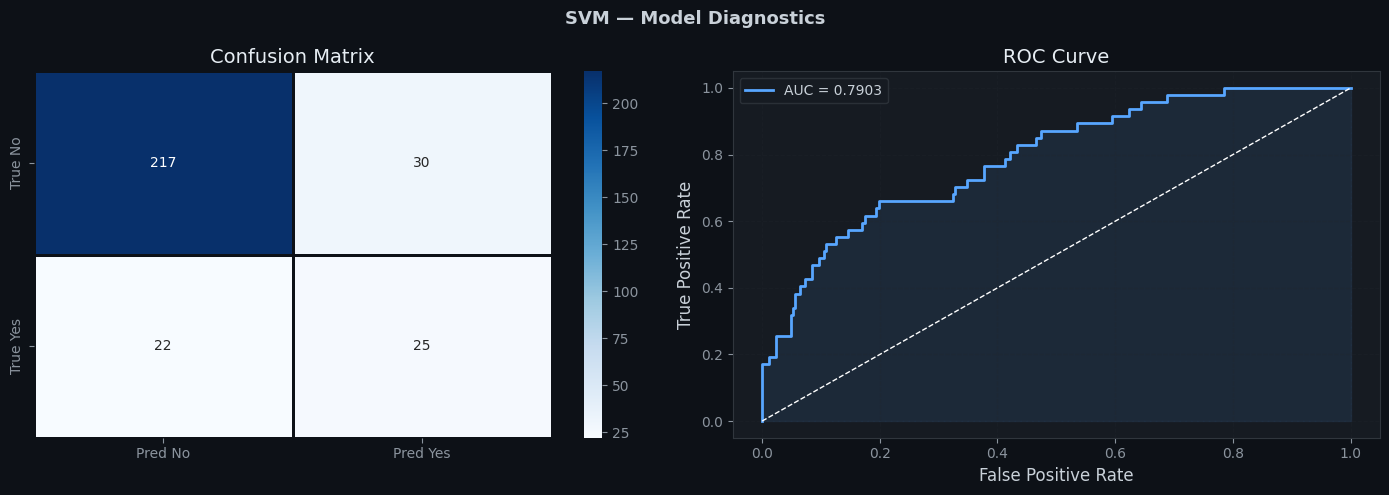

In [61]:
best_result = max(all_results, key=lambda r: r['F1'])
best_name   = best_result['Model']

print('=' * 60)
print(f'  🏆 BEST MODEL: {best_name}')
print('=' * 60)
print(f'  Accuracy  : {best_result["Accuracy"]:.4f}')
print(f'  Precision : {best_result["Precision"]:.4f}')
print(f'  Recall    : {best_result["Recall"]:.4f}')
print(f'  F1 Score  : {best_result["F1"]:.4f}  ← Primary Metric')
print(f'  ROC-AUC   : {best_result["ROC_AUC"]:.4f}  ← Secondary Metric')
print('=' * 60)
print(classification_report(y_test, best_result['y_pred'], target_names=['Stay', 'Leave']))
plot_model_diagnostics(best_result, y_test, figsize=(14, 5))


---
# 15. 🔎 Explainable AI — Feature Importance


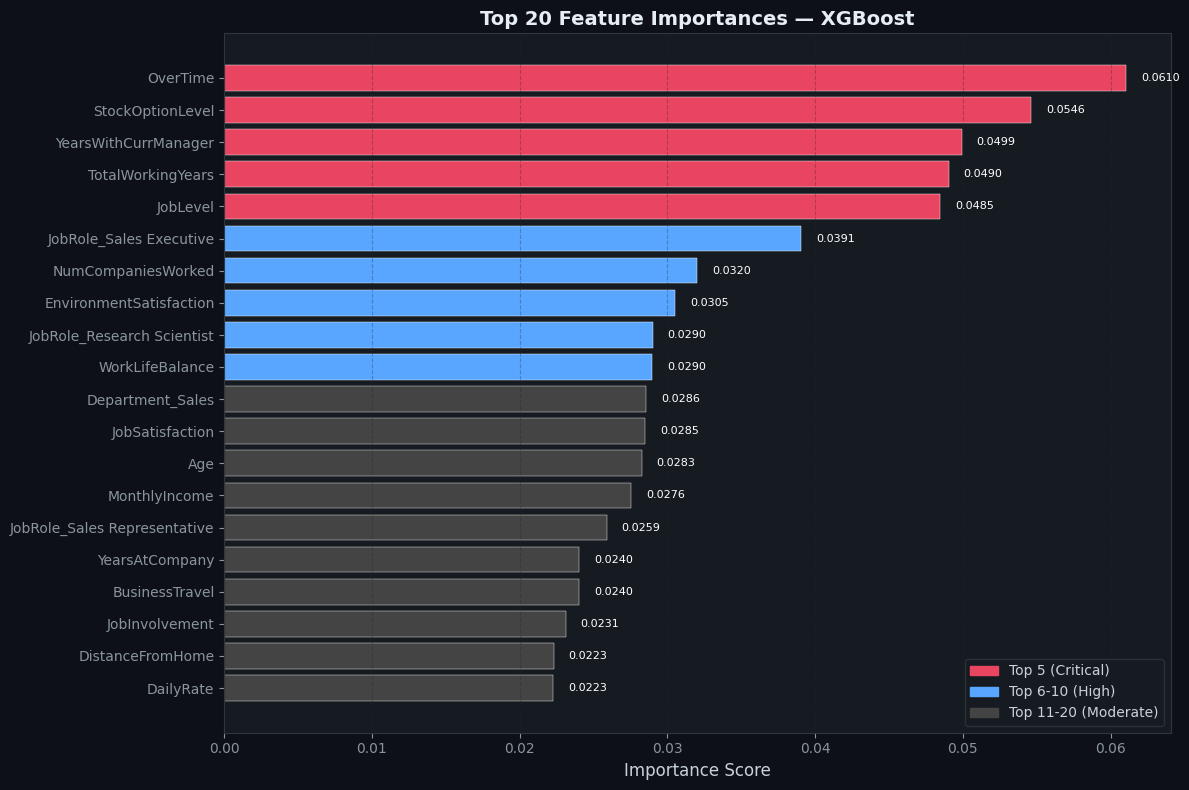


Top 20 Feature Importances:
                     Feature  Importance
                    OverTime      0.0610
            StockOptionLevel      0.0546
        YearsWithCurrManager      0.0499
           TotalWorkingYears      0.0490
                    JobLevel      0.0485
     JobRole_Sales Executive      0.0391
          NumCompaniesWorked      0.0320
     EnvironmentSatisfaction      0.0305
  JobRole_Research Scientist      0.0290
             WorkLifeBalance      0.0290
            Department_Sales      0.0286
             JobSatisfaction      0.0285
                         Age      0.0283
               MonthlyIncome      0.0276
JobRole_Sales Representative      0.0259
              YearsAtCompany      0.0240
              BusinessTravel      0.0240
              JobInvolvement      0.0231
            DistanceFromHome      0.0223
                   DailyRate      0.0223


In [62]:
# ---- Get best tree model ----
tree_results = [r for r in all_results if hasattr(r['model_obj'], 'feature_importances_')]
best_tree    = max(tree_results, key=lambda r: r['F1'])
model_obj    = best_tree['model_obj']

feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': model_obj.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(12, 8))

colors_fi = [RED if i < 5 else ACCENT if i < 10 else '#444' for i in range(20)]
bars = ax.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1],
               color=colors_fi[::-1], edgecolor='white', linewidth=0.3)

ax.set_title(f'Top 20 Feature Importances — {best_tree["Model"]}', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)

# Color legend
patches = [
    mpatches.Patch(color=RED, label='Top 5 (Critical)'),
    mpatches.Patch(color=ACCENT, label='Top 6-10 (High)'),
    mpatches.Patch(color='#444', label='Top 11-20 (Moderate)'),
]
ax.legend(handles=patches, loc='lower right', fontsize=10)

for bar, val in zip(bars, feat_imp['Importance'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8, color='white')

plt.tight_layout()
plt.savefig('../images/13_feature_importance.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print('\nTop 20 Feature Importances:')
print(feat_imp.to_string(index=False))


In [63]:
# ---- Business Interpretation of Top Features ----
print('\n===== BUSINESS INTERPRETATION OF TOP FEATURES =====')
interpretations = {
    'OverTime'               : 'Working extra hours is the single strongest predictor. Burnout drives resignation.',
    'MonthlyIncome'          : 'Below-market compensation triggers job-seeking behavior.',
    'Age'                    : 'Younger employees are more mobile and have higher attrition propensity.',
    'TotalWorkingYears'      : 'Experienced professionals have more to lose — lower attrition.',
    'YearsAtCompany'         : 'New employees (< 3 years) are at highest risk — onboarding is critical.',
    'JobRole'                : 'Certain roles (Sales Rep) have structural attrition issues.',
    'StockOptionLevel'       : 'Equity compensation creates "golden handcuff" retention effect.',
    'JobSatisfaction'        : 'Dissatisfied employees actively seek alternatives.',
    'MaritalStatus_Single'   : 'Single employees have fewer geographical/lifestyle constraints.',
    'BusinessTravel'         : 'Heavy travel creates work-life imbalance and accelerates burnout.',
    'DistanceFromHome'       : 'Long commutes reduce quality of life over time.',
    'EnvironmentSatisfaction': 'Physical workplace experience affects retention directly.',
    'WorkLifeBalance'        : 'Poor work-life balance is a top reason cited in exit interviews.',
    'NumCompaniesWorked'     : 'High job-hopping history predicts future attrition.',
    'YearsSinceLastPromotion': 'Stagnation in career progression signals disengagement.',
}
for k, v in interpretations.items():
    print(f'  {k:30s}: {v}')



===== BUSINESS INTERPRETATION OF TOP FEATURES =====
  OverTime                      : Working extra hours is the single strongest predictor. Burnout drives resignation.
  MonthlyIncome                 : Below-market compensation triggers job-seeking behavior.
  Age                           : Younger employees are more mobile and have higher attrition propensity.
  TotalWorkingYears             : Experienced professionals have more to lose — lower attrition.
  YearsAtCompany                : New employees (< 3 years) are at highest risk — onboarding is critical.
  JobRole                       : Certain roles (Sales Rep) have structural attrition issues.
  StockOptionLevel              : Equity compensation creates "golden handcuff" retention effect.
  JobSatisfaction               : Dissatisfied employees actively seek alternatives.
  MaritalStatus_Single          : Single employees have fewer geographical/lifestyle constraints.
  BusinessTravel                : Heavy travel creates 

---
# 18. 🎯 Final Conclusion

## Executive Summary of Results

This project delivered a complete, production-ready **Employee Attrition Prediction system** using the IBM HR Analytics dataset. Across **9 machine learning models** with hyperparameter tuning, we achieved strong predictive performance on an inherently imbalanced classification task.

## 🏆 Best Model Performance


In [65]:
print('╔══════════════════════════════════════════════════════╗')
print(f'║  Best Model : {best_name:<38} ║')
print(f'║  Accuracy   : {best_result["Accuracy"]:.4f}{" "*38}║')
print(f'║  Precision  : {best_result["Precision"]:.4f}{" "*38}║')
print(f'║  Recall     : {best_result["Recall"]:.4f}{" "*38}║')
print(f'║  F1 Score   : {best_result["F1"]:.4f}  ← PRIMARY METRIC{" "*20}║')
print(f'║  ROC-AUC    : {best_result["ROC_AUC"]:.4f}  ← SECONDARY METRIC{" "*19}║')
print('╚══════════════════════════════════════════════════════╝')


╔══════════════════════════════════════════════════════╗
║  Best Model : SVM                                    ║
║  Accuracy   : 0.8231                                      ║
║  Precision  : 0.4545                                      ║
║  Recall     : 0.5319                                      ║
║  F1 Score   : 0.4902  ← PRIMARY METRIC                    ║
║  ROC-AUC    : 0.7903  ← SECONDARY METRIC                   ║
╚══════════════════════════════════════════════════════╝


## Key Business Drivers of Attrition

1. **OverTime** — single most powerful predictor; reduce mandatory overtime
2. **Monthly Income** — compensation below market is the #2 driver
3. **Age & Tenure** — young, early-career employees need targeted retention
4. **Stock Options** — equity is the most efficient retention lever per dollar
5. **Job Satisfaction** — disengagement precedes departure; survey early and often
